<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **1. Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

# **2. Importing necessary libraries**

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 3.5 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
arviz 0.22.0 requires matplotlib>=3.

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# This will help in making the Python code more structured automatically (good coding practice)
# %load_ext nb_black

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libaries for statistical testing
from scipy.stats import chi2_contingency

# Libraries to tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Libraries to be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# Libraries to impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# Libraries to oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries to do hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Libraries to define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# Libraries to supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libraries to help with model building (base estimators)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Libraries to suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libraries to supress warnings
import warnings

warnings.filterwarnings("ignore")

# **3. Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Module 5 Ensemble Techniques & Model Tuning/Week 4/EasyVisa.csv')

In [5]:
df = data.copy()

# **4. Overview of the Dataset**

* Observations

* Sanity checks

In [6]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [7]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [8]:
df.shape

(25480, 12)

- There are 25,480 observations (rows) and 12 variables (columns) in this dataset.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- Nine of the features are of object data type while only 3 features are numeric. The majority of these variables will have to be converted since Bagging and Boosting models require all input features to be numeric.

In [10]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [11]:
df.duplicated().sum()

np.int64(0)

- There are neither missing nor duplicated observations in the dataset.

# **5. Exploratory Data Analysis (EDA)**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

## **5.1. Statistical Summary of the Data**

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


- `no_of_employees` has a minimum of -26, which is not possible.This must be a data entry error.
- There might be large outliers in `no_of_employees` and `prevailing_wage` as indicated by the large difference between the 3rd quartile and the maximum value.
- The oldest employer company in the dataset was established in 1800 while the newest was from 2016.

In [13]:
df.loc[df['no_of_employees'] < 0].shape

(33, 12)

- The 33 observations with negative values can be either considered outliers and removed, however, that will lead to the loss of potentially valuable information. Instead, we will consider them as data entry errors and proceed with taking the absolute values of `no_of_employees`.

In [14]:
# absolute values of no_of_employees
df['no_of_employees'] = abs(df['no_of_employees'])

In [15]:
# verifying the minimum value in no_of_employees
df['no_of_employees'].min()

11

In [16]:
df.describe(include='object').T

,count,unique,top,freq
case_id,25480,25480,EZYV25480,1
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


- Approximately 67% of the visa applications in the dataset were certified, making the classes moderately imbalanced in the target variable.
- Since each observation for `case_id` is unique, this variable can be removed. It does not contain any useful information for our predictive model.

In [17]:
df = df.drop('case_id', axis=1)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  object 
 10  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


## **5.2. Univariate Analysis**

### Numeric Features

In [19]:
# Function to plot both a boxplot and histogram for a single numeric feature.
# Helps visualize the distribution, detect skewness, and identify outliers, with mean and median lines for reference.

def histogram_boxplot(data, feature, figsize=(8, 5), kde=False, bins=None):
    """
    Plotting a boxplot and histogram for a single numeric feature.

    Parameters:
    - data: DataFrame containing the data.
    - feature: The column name of the feature to plot.
    - figsize: Tuple controlling the figure size.
    - kde: Choosing whether to overlay a kernel density estimate on the histogram.
    - bins: Setting the number of bins for the histogram (optional).
    """

    # Skipping if the feature is not numeric
    if not pd.api.types.is_numeric_dtype(data[feature]):
        print(f"Skipping non-numeric column: {feature}")
        return

    # Creating a figure with 2 subplots stacked vertically
    # Using the first for the boxplot, the second for the histogram; sharing the x-axis
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,  # Defining two rows: one for the boxplot, one for the histogram
        sharex=True,  # Sharing the x-axis between both plots
        gridspec_kw={"height_ratios": (0.25, 0.75)},  # Assigning less vertical space to the boxplot
        figsize=figsize  # Setting the overall figure size
    )

    # Plotting the boxplot on the top subplot
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="violet")

    # Plotting the histogram on the bottom subplot
    sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist, bins=bins)

    # Adding a vertical line showing the mean of the feature
    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")

    # Adding a vertical line showing the median of the feature
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label="Median")

    # Showing the legend for mean and median lines
    ax_hist.legend()

    # Adding a title at the top of the figure
    plt.suptitle(f"Histogram & Boxplot for '{feature}'", fontsize=16)

    # Adjusting layout to prevent overlap
    plt.tight_layout()

    # Displaying the final plot
    plt.show()

In [20]:
# Function to automatically generate boxplot + histogram visualizations.

def auto_histogram_boxplot(data, features=None, **kwargs):
    """
    Runs histogram_boxplot for multiple features.

    features: list of column names to plot; if None, auto-selects numeric columns
    kwargs: passed to histogram_boxplot (e.g., figsize, kde, bins)

    Adds visual dividers between plots.
    """
    if features is None:
        features = data.select_dtypes(include='number').columns

    for feature in features:
        print("\n" + "=" * 160)
        print(f"    ")
        print("=" * 160 + "\n")
        histogram_boxplot(data, feature, **kwargs)


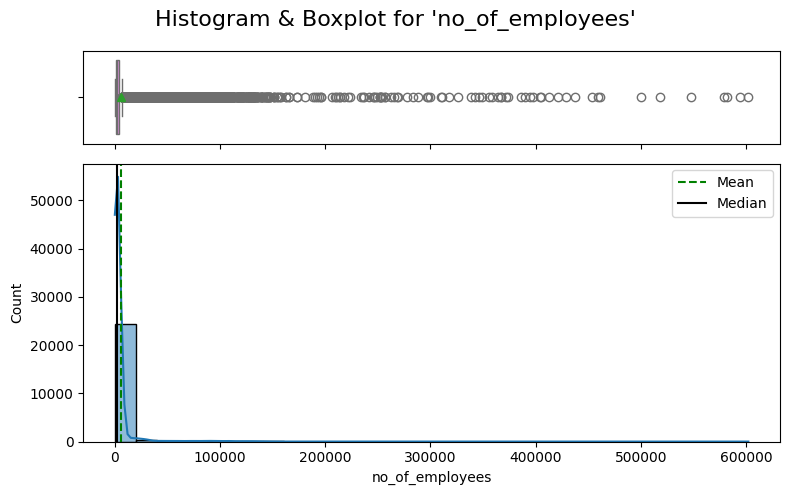

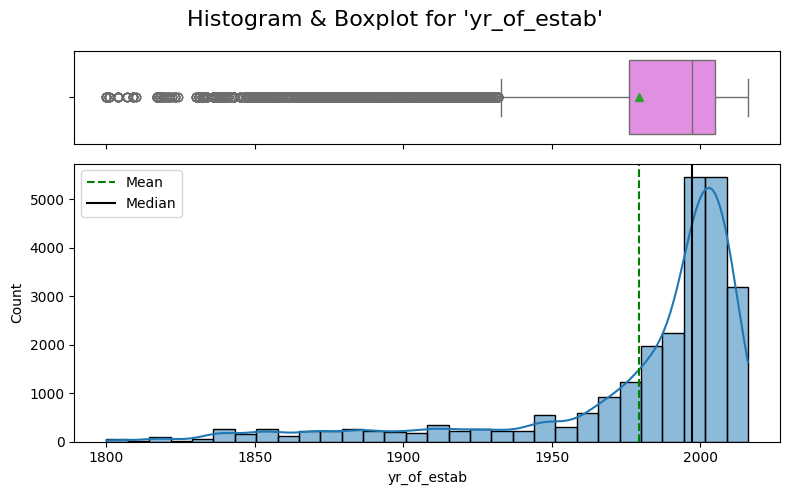

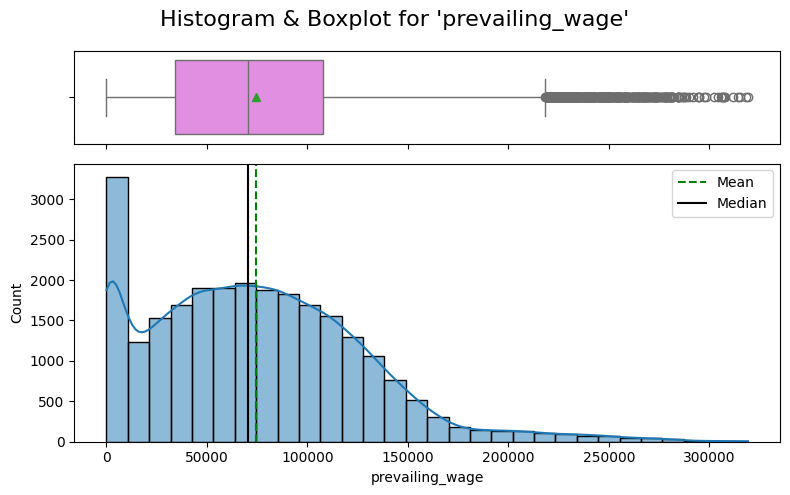

In [21]:
auto_histogram_boxplot(df, kde=True, bins=30)

### Observations on Numeric Features
1. **Number of employees**
  - The distribution is heavily right-skewed as shown by the histogram. This is further reinforced by the larger mean compared to the median.
  - The boxplot reveals many extreme outliers far above the upper whisker, indicating high variability in larger companies.
  - The majority of employers have relatively few employees (densely packed near 0).
  - *Due to high skewness and outliers, a log transformation might help normalize the distribution for modeling.*

2. **Year of Establishment**
  - In contrast to `no_of_employees`, `yr_of_estab` is heavily left-skewe where the majority of the companies in the dataset were established after 1980. This skewness is further supported by the lower mean value compared to the median.
  - The boxplot shows extreme outliers for businesses established before the 1930s.
  - *Very early years (e.g., before 1850) might be anomalies or data entry errors worth validating.*
3. **Prevailing Wage**
  - The histogram shows a right skewed distribution, with most wages clustered on the lower end and a long tail of high wages. Additionally, the mean is greater than the median, confirming skewness due to high-wage outliers.
  - The boxplot reveals many high-end outliers, possibly for senior or specialized roles.
  - The visible histogram spike near 0 USD is likely caused by hourly wages not yet converted to annual equivalents (since there could be different units for wage and the minimum value in the statistical summary is ~2 USD). We will need to normalize all wages to a common unit (e.g., yearly) for meaningful comparison and modeling.

### Categorical Features

In [22]:
# Function to create a barplot for a categorical feature, displaying either raw counts or percentages as labels on each bar.

def labeled_barplot(data, feature, perc=False, n=None, title=None, palette='viridis'):
    """
    Creating a barplot with counts or percentages labeled on top.

    Parameters:
    - data: the DataFrame
    - feature: the categorical column to plot
    - perc: setting True will display percentages instead of counts
    - n: limiting to top n most frequent categories
    - palette: colormap for the barplot
    """
    # Calculating total number of values for percentage calculation
    total = len(data[feature])

    # Counting the number of unique category levels
    count = data[feature].nunique()

    # Setting figure size based on number of categories (or top n)
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    # Rotating x-axis labels for readability and setting font size
    plt.xticks(rotation=90, fontsize=15)

    # Creating a barplot ordered by frequency
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
        palette=palette # Added palette parameter here
    )

    # Looping through each bar to annotate with count or percentage
    for p in ax.patches:
        if perc == True:
            # Calculating and formatting percentage label
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            # Using raw count as label
            label = p.get_height()

        # Calculating x and y positions for label placement
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        # Adding the label above the bar
        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    # Adding a title to the barplot
    if title is None:
      plt.title(f"Barplot for '{feature}'", fontsize=16)
    else:
      plt.title(title, fontsize=16)


    # Displaying the plot
    plt.show()

In [23]:
# Function to automatically generate labeled barplots for multiple categorical features in a dataset.
# Displays counts or percentages.

def auto_barplots(data, features=None, perc=True, n=None, titles=None):
    """
    Automating labeled barplot creation for multiple categorical features.

    Parameters:
    - data: the DataFrame
    - features: list of column names to plot; if None, selecting categorical columns automatically
    - perc: setting True will display percentages
    - n: limiting to top n categories
    """
    # Selecting categorical features if not provided
    if features is None:
        features = data.select_dtypes(include=["object", "category"]).columns

    # Looping through each feature and generating a plot
    for feature in features:
        # Printing a visual divider
        print("\n" + "=" * 160)
        print(" " * 4)
        print("=" * 160 + "\n")

        # Calling the labeled barplot function
        labeled_barplot(data, feature, perc=perc, n=n)


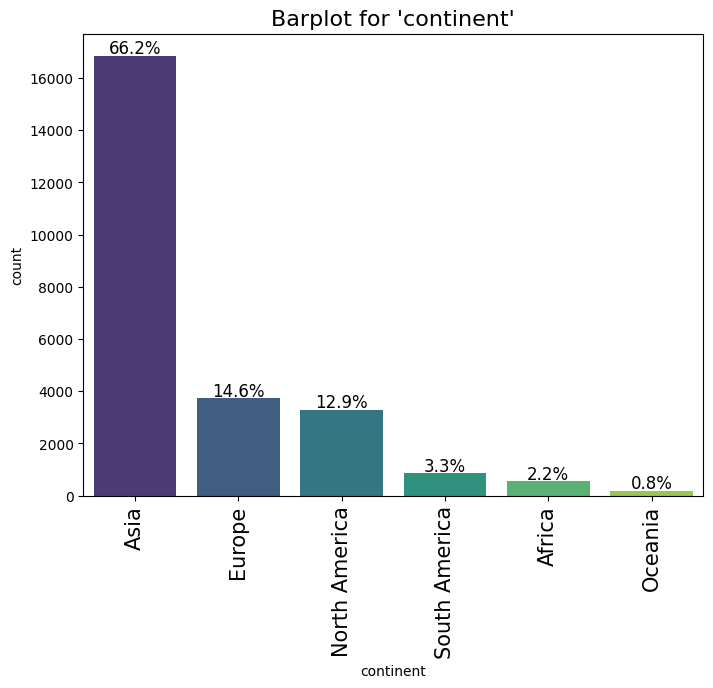

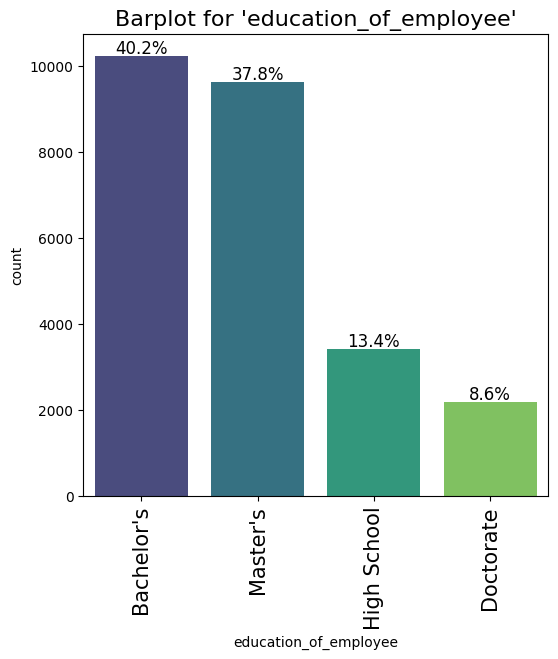

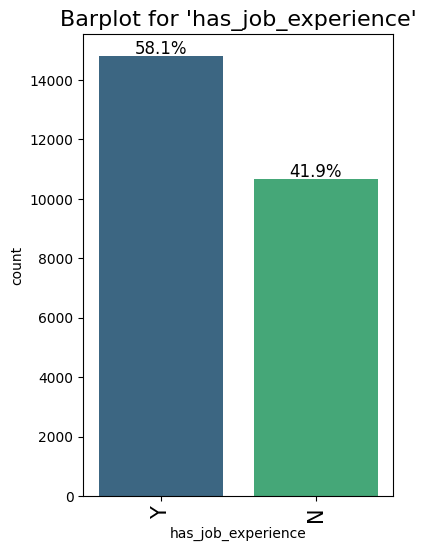

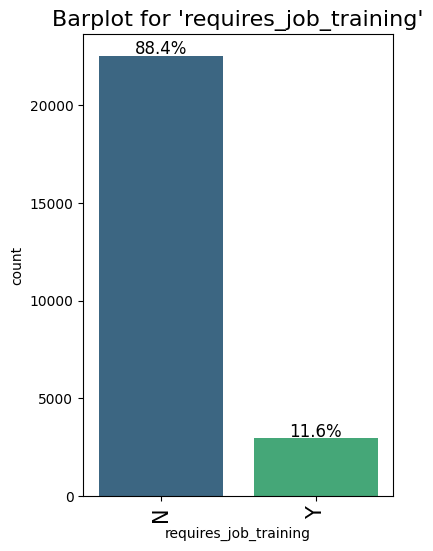

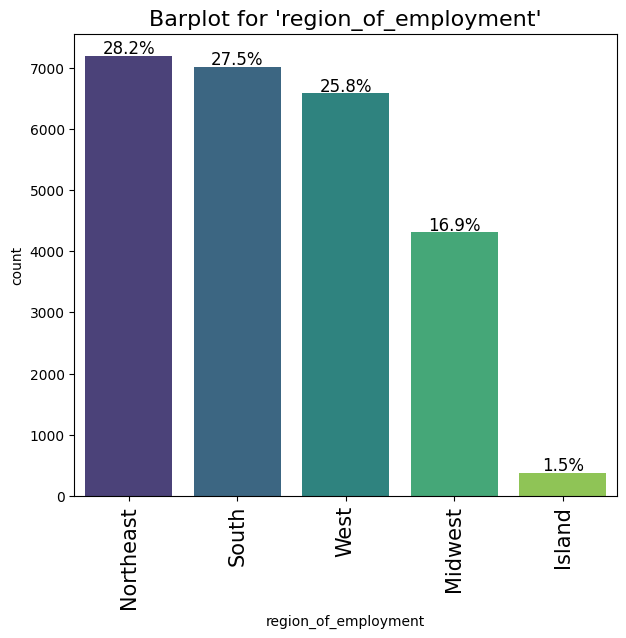

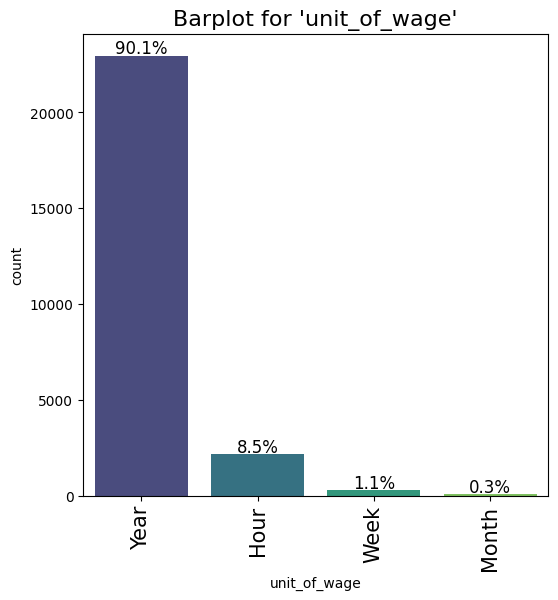

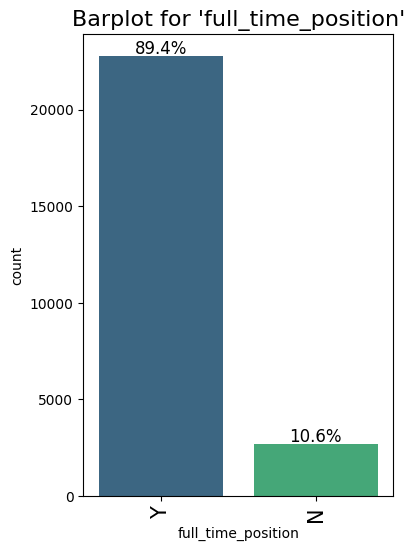

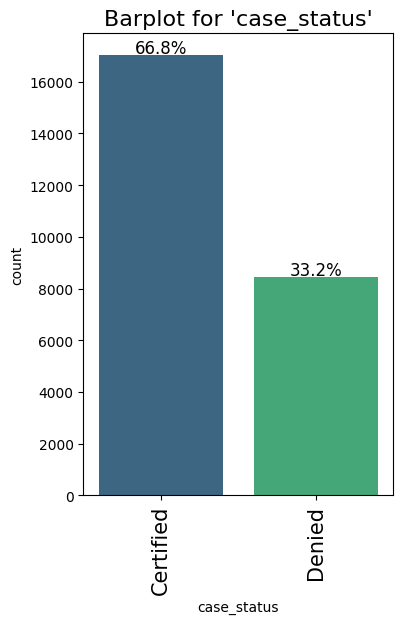

In [24]:
auto_barplots(df)

### Observations on Categorical Features

1. **Continent**

  - The dataset is highly dominated by applicants from **Asia (66.2%)**, with much smaller representation from Europe (14.6%) and North America (12.9%).
  - Applicants from **South America, Africa, and Oceania** form a very small portion of the data, each under 4%.
  - This skewed distribution could influence model predictions and may warrant grouping or balancing in some use cases.

2. **Education of Employee**

  - Most applicants hold either a **Bachelor's (40.2%)** or **Master's (37.8%)** degree.
  - Only a small fraction have a **Doctorate (8.6%)** or **High School diploma (13.4%)**, indicating that most foreign labor applicants are highly educated.
  - Education level may be a strong predictor in determining visa approval likelihood.

3. **Has Job Experience**

  - **58.1%** of applicants have prior job experience, while **41.9%** do not.
  - This shows a relatively balanced distribution, with experience slightly more common.
  - Prior job experience may be another key factor influencing certification.

4. **Requires Job Training**

  - A large majority (**88.4%**) of positions do **not** require job training, while only **11.6%** do.
  - This suggests most roles being filled are expected to be handled by already skilled workers.

5. **Region of Employment**

  - The regions are fairly evenly distributed among **Northeast (28.2%)**, **South (27.5%)**, and **West (25.8%)**, while **Midwest (16.9%)** has less representation.
  - **Island regions** make up only **1.5%**, which could indicate niche or less frequent labor demands there.
  - *Geographical location may correlate with industry type and wage expectations.*

6. **Unit of Wage**

  - A significant majority (**90.1%**) of wages are reported on a **yearly** basis.
  - A smaller portion are reported as **hourly (8.5%)**, while **weekly** and **monthly** account for a negligible percentage (1.1% and 0.3%, respectively).
  - This aligns with the earlier observation of low wage values due to unconverted hourly wages and highlights the importance of unit standardization.

7. **Full-Time Position**

  - **89.4%** of positions are marked as **full-time**, suggesting that most visa applications are for stable, long-term employment.
  - Only **10.6%** represent part-time roles, which may have different approval dynamics.

**Question # 1**. What is the distribution of visa case statuses (certified vs. denied)?

- The target variable `case_status` is moderately imbalanced, with **66.8%** of applications being **certified** and **33.2%** being **denied**.

- While not severely skewed, this imbalance may still affect classification model performance, especially on the minority class (Denied).

- To address this, techniques such as oversampling, undersampling, and class weighting can be used to improve recall and precision for the denied class.

## **5.3. Bivariate Analysis**

**Leading Questions**

1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

### Heatmap Correlation (Numeric Features)

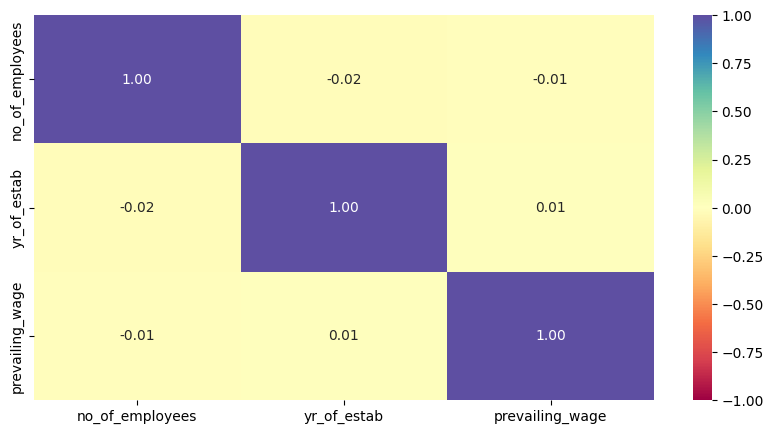

In [25]:
# Selecting numeric features to plot a heatmap of correlation
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- There is no observed correlation between the numeric features (`no_of_employees`, `yr_of_estab`, and `prevailing wage`).

### Functions for Plotting

In [26]:
# For categorical variables
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart with percentage labels.

    data: dataframe
    predictor: independent variable
    target: target variable
    """

    # Counting the number of unique categories in the predictor variable
    count = data[predictor].nunique()

    # Identifying the less frequent class in the target variable (used for sorting)
    sorter = data[target].value_counts().index[-1]

    # Creating and printing a cross-tabulation of absolute counts between predictor and target
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)

    # Creating a normalized cross-tabulation to show class distribution proportions
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )

    # Plotting the stacked bar chart using the viridis palette
    ax = tab.plot(
        kind="bar",
        stacked=True,
        figsize=(count + 5, 5),
        color=sns.color_palette("viridis", n_colors=tab.shape[1]),
    )

    # Adding percentage data labels
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        if height > 0.01:  # only label segments >1%
            x = p.get_x() + width / 2
            y = p.get_y() + height / 2
            ax.text(
                x,
                y,
                f"{height * 100:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
            )

    # Customizing legend placement
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
    plt.ylabel("Proportion")
    plt.title(f"Stacked Barplot of {predictor} vs. {target}")
    plt.tight_layout()
    plt.show()


In [27]:
# For numerical variables
def distribution_plot_wrt_target(data, predictor, target):
    """
    Plotting distribution and boxplots of a numerical predictor variable with respect to the target.

    data: dataframe
    predictor: numerical independent variable
    target: categorical target variable (e.g., binary classification)
    """
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Creating subplots: 2 rows × 2 columns
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # Extracting unique target values (e.g., 'Certified', 'Denied')
    target_uniq = data[target].unique()

    # Selecting two colors from the viridis palette for visual consistency
    viridis_colors = sns.color_palette("viridis", n_colors=2)

    # Plotting histogram and KDE for the first class in target
    axs[0, 0].set_title("Distribution of " + predictor + " for target = " + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color=viridis_colors[0],
        stat="density",  # Normalizing to show probability density
    )

    # Plotting histogram and KDE for the second class in target
    axs[0, 1].set_title("Distribution of " + predictor + " for target = " + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color=viridis_colors[1],
        stat="density",
    )

    # Plotting a boxplot to show value spread and central tendency across classes
    axs[1, 0].set_title("Boxplot of " + predictor + " by " + target)
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 0],
        palette="gist_rainbow"
    )

    # Plotting the same boxplot but hiding extreme outliers
    axs[1, 1].set_title("Boxplot (no outliers) of " + predictor + " by " + target)
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow"
    )

    # Adjusting layout to prevent label overlap
    plt.tight_layout()
    plt.show()


### Education of Employee vs Case Status

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


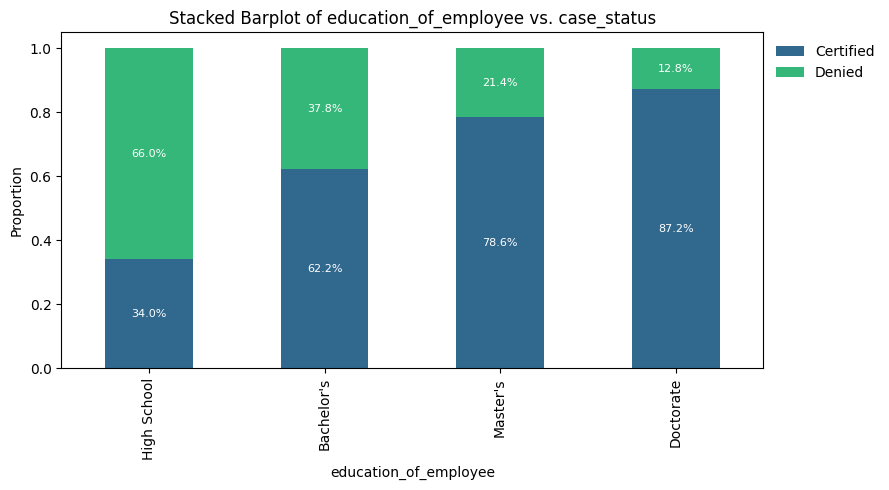

In [28]:
stacked_barplot(df, "education_of_employee", "case_status")

**Question # 2**. How does the education level of employees impact visa approval rates?
- The higher the level of education of the employee, the higher visa approval rate is (i.e., Certified).
  - Doctorate holders have the highest approval rate (87.2%).
  - Master’s degree holders follow closely (78.6%).
  - Bachelor’s degree holders have a moderate approval rate (62.2%).
  - High School graduates have the lowest approval rate (34.0%).

### Has Job Experience vs Case Status

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


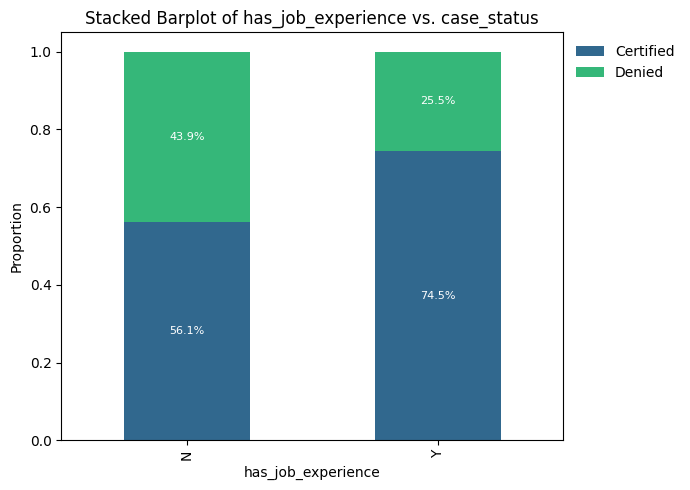

In [29]:
stacked_barplot(df, "has_job_experience", "case_status")

In [30]:
#Chi-Square test of independence to statistically confirm if this observed difference is significant between employees with job experience and those without

# Create a contingency table of 'has_job_experience' and 'case_status'
contingency_table = pd.crosstab(df['has_job_experience'], df['case_status'])

# Perform the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square test of independence between 'has_job_experience' and 'case_status':")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Interpret the result
alpha = 0.05
print("\nInterpretation:")
if p < alpha:
    print(f"With a P-value of {p:.2f} (which is less than {alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in visa approval rates between employees with job experience and those without.")
else:
    print(f"With a P-value of {p:.2f} (which is greater than or equal to {alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in visa approval rates between employees with job experience and those without.")

Chi-Square test of independence between 'has_job_experience' and 'case_status':
Chi-Square Statistic: 940.0581
P-value: 0.0000
Degrees of Freedom: 1
Expected Frequencies Table:
case_status         Certified   Denied
has_job_experience                    
N                    7131.798 3546.202
Y                    9886.202 4915.798

Interpretation:
With a P-value of 0.00 (which is less than 0.05), we reject the null hypothesis.
There is a statistically significant difference in visa approval rates between employees with job experience and those without.


**Question # 3**. Is there a significant difference in visa approval rates between employees with and without prior job experience?
- Based on the stacked plot, the visa approval rate is approximately 18.4% higher in the group of employees with prior job experience.
- Moreover, the Chi-Squared Test demonstrates that there is a significant difference in visa approval rates between employees with and without prior job experience.

### Prevailing Wage vs Case Status

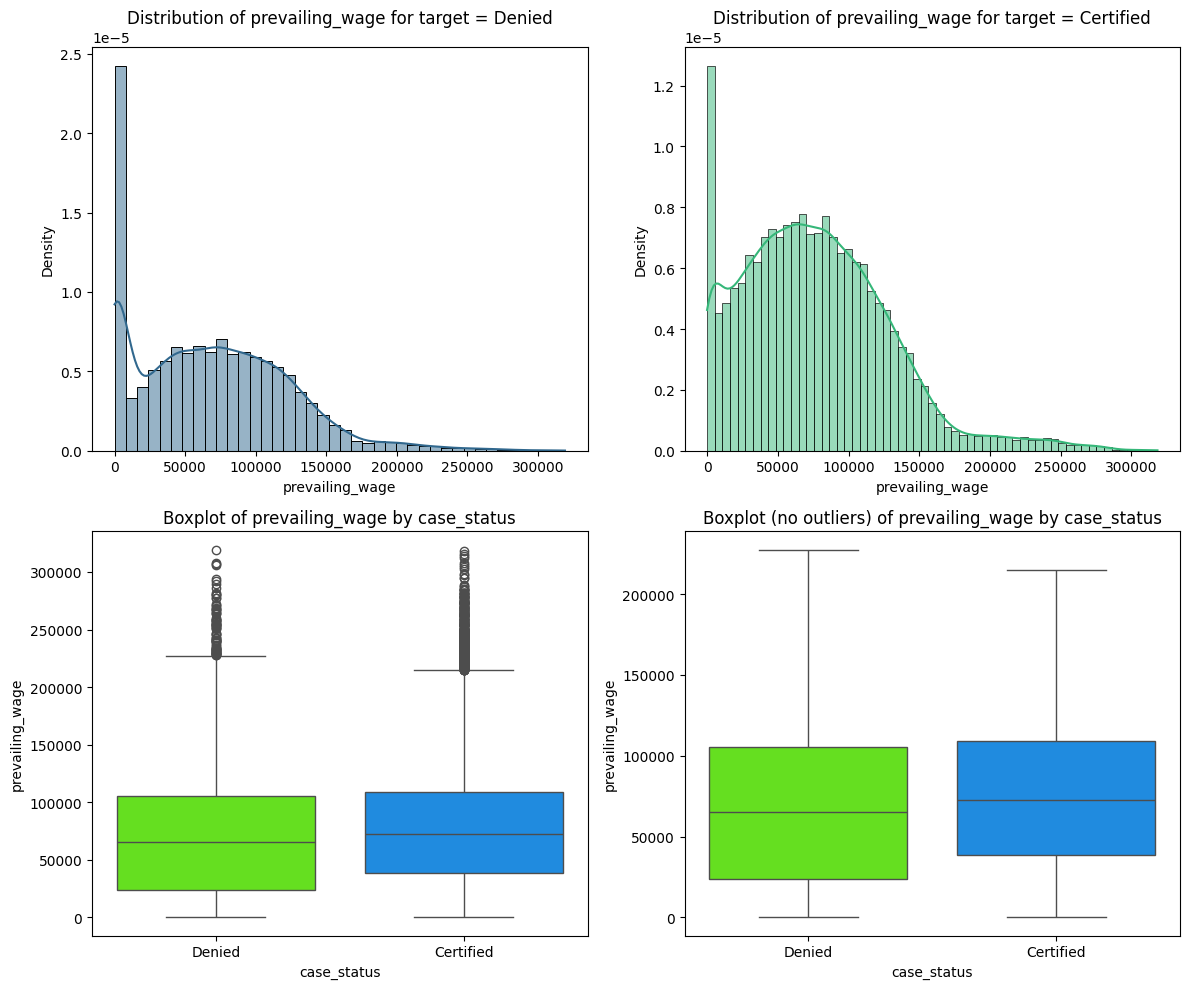

In [31]:
distribution_plot_wrt_target(df, "prevailing_wage", "case_status")

**Question # 4**. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?

- Both Certified and Denied applications show a dense concentration of prevailing wages in the $50k–100k range, suggesting this is a common wage band across both outcomes.

- However, Denied applications have a higher peak near the very low end of the wage scale (close to $0), reflecting low-wage roles or unconverted hourly wages that skew the distribution.

- While the median wage for Certified cases is slightly higher than for Denied cases (as shown in the boxplots), the difference is very modest, and both distributions have similar interquartile ranges once outliers are removed.

- The Certified group shows more extreme high-end outliers, though Denied cases also reach high wages, indicating that high wages do not guarantee approval, and low wages do not guarantee denial.

- Overall, while higher wages tend to correlate with certification, the effect is not sharply pronounced. This indicates that wage may not be one of the main influencing factors for visa approval.



### Region of Employment vs Case Status

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


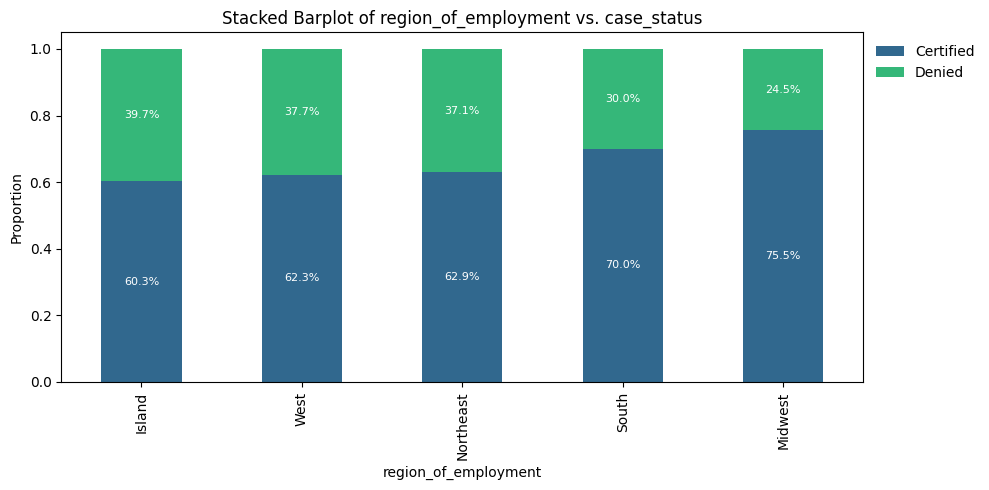

In [32]:
stacked_barplot(df, "region_of_employment", "case_status")

**Question # 5**. Do certain regions in the US have higher visa approval rates compared to others?

- Midwestern and Southern regions (70-75%) appear to have more favorable outcomes for visa applicants compared to Northeast, West, and Island (60-63%).

- This could be due to regional labor demand, industry composition, or application quality, but more data attributes and further analysis would be needed to understand why.

### Number of Employees vs Case Status

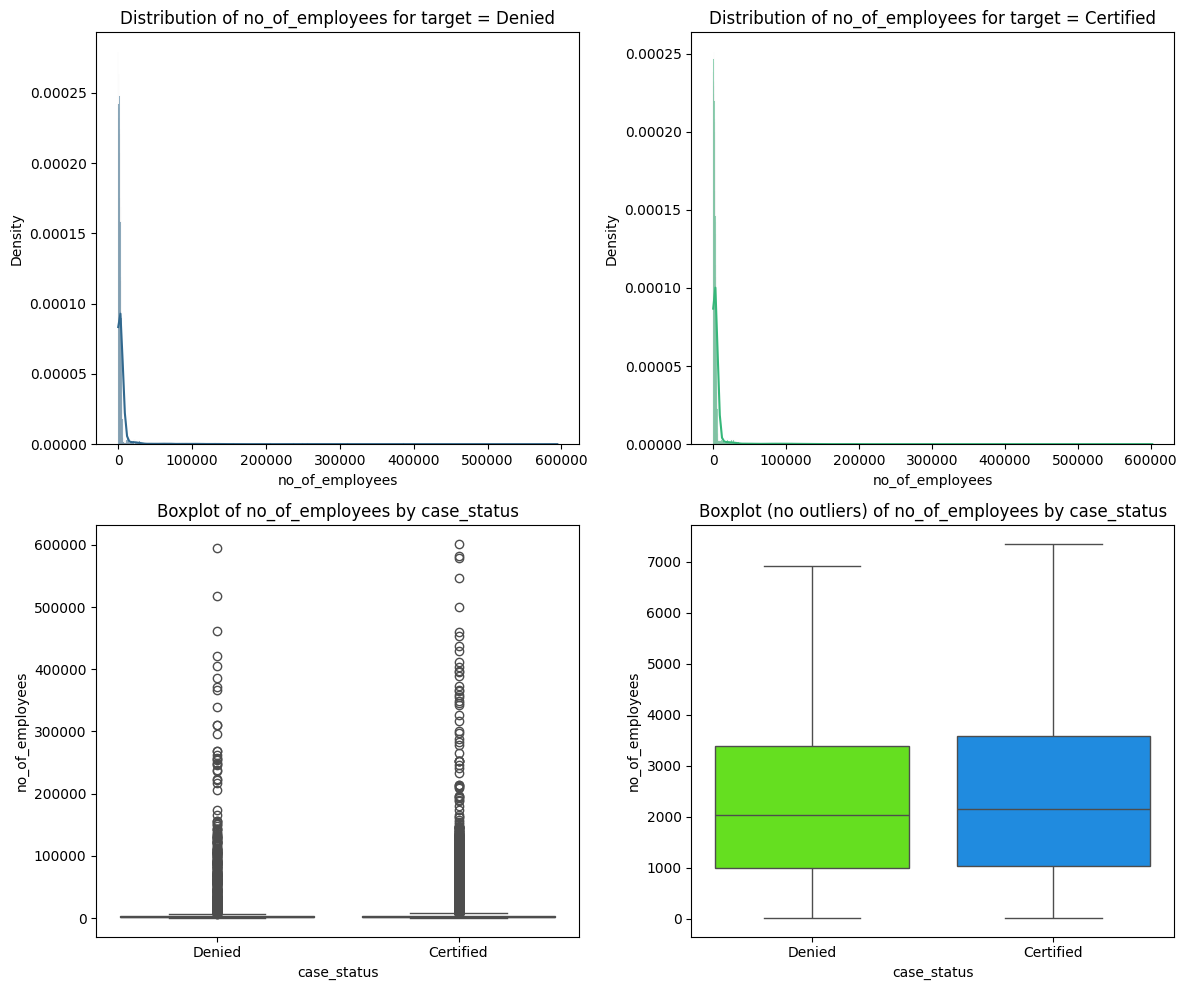

In [33]:
distribution_plot_wrt_target(df, "no_of_employees", "case_status")

**Question # 6**. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?

- The distributions for both Certified and Denied applications are heavily right-skewed, with most companies having a small workforce.

- Certified applications come from slightly larger companies as shown by slightly higher median and range. This could be due to better legal resources or clearer reasons for hiring foreign workers, however, the difference in size is minimal.

- The distributions for Certified and Denied cases largely overlap.

- Overall, the number of employess (i.e., company size) does not appear to be a strong influencing factor in visa approval.

### Origin Continent of Employee vs Case Status

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


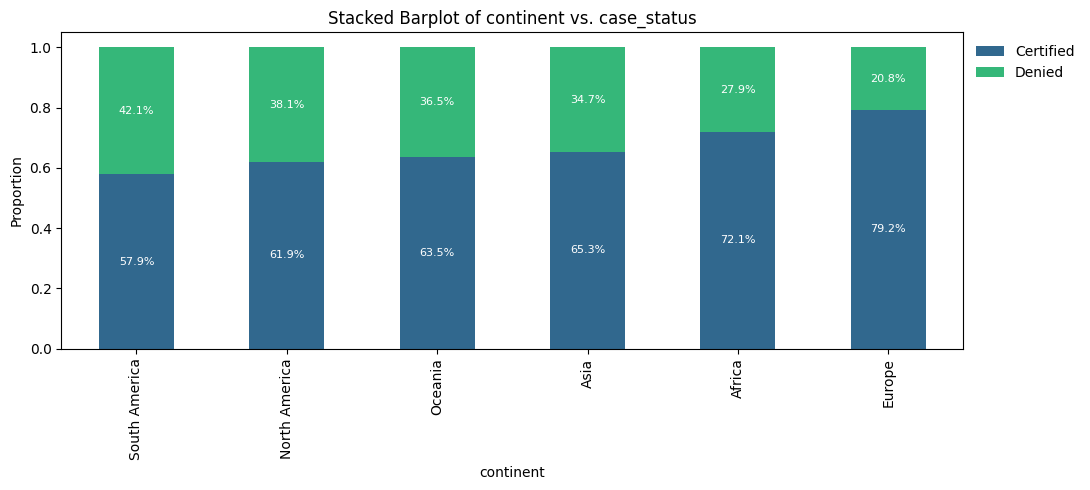

In [34]:
stacked_barplot(df, "continent", "case_status")

**Question # 7**. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

- Europe has the highest visa approval rate (79.2%), followed by Africa (72.1%) and Asia (65.3%).

- Oceania (63.5%) and North America (61.9%) have moderate approval rates.

- South America appears to have the lowest visa approval rate (57.9%).

### Requires Job Training vs Case Status

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


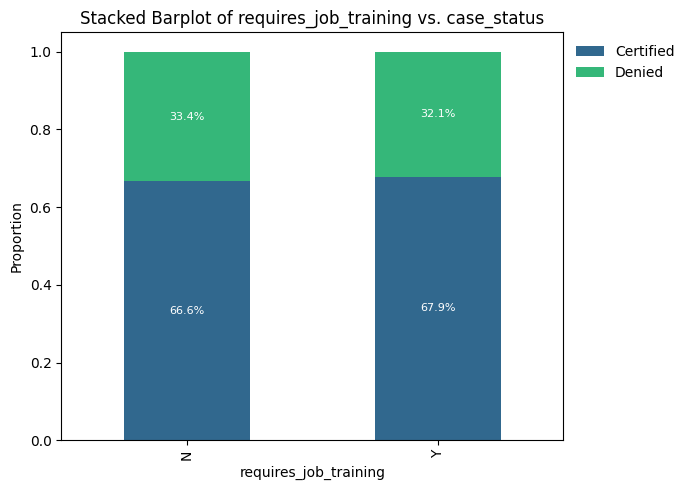

In [35]:
stacked_barplot(df, "requires_job_training", "case_status")

- Job training requirement does not seem to impact visa approval rate. Approval proportions for both jobs with training (66.6%) and without (67.9%) are very similar.

### Full Time Position vs Case Status

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


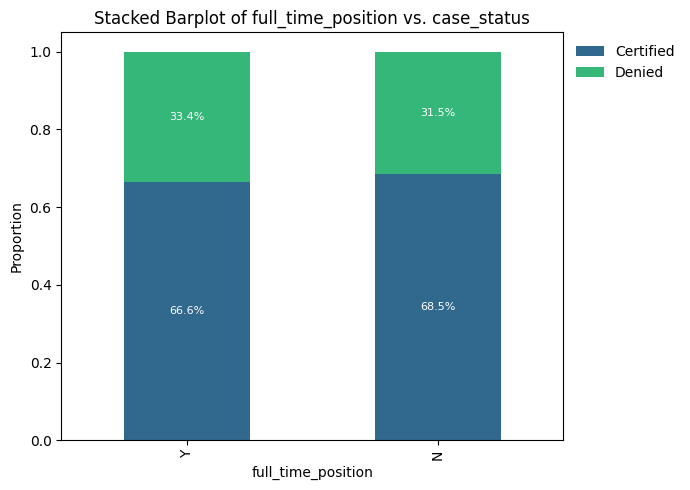

In [36]:
stacked_barplot(df, "full_time_position", "case_status")

- Whether the job is full-time or not does not show a meaningful difference in visa approval rates. Approval proportions for both full-time (66.6%) and non–full-time (68.5%) roles are very similar.

### Year of Establishment vs Case Status

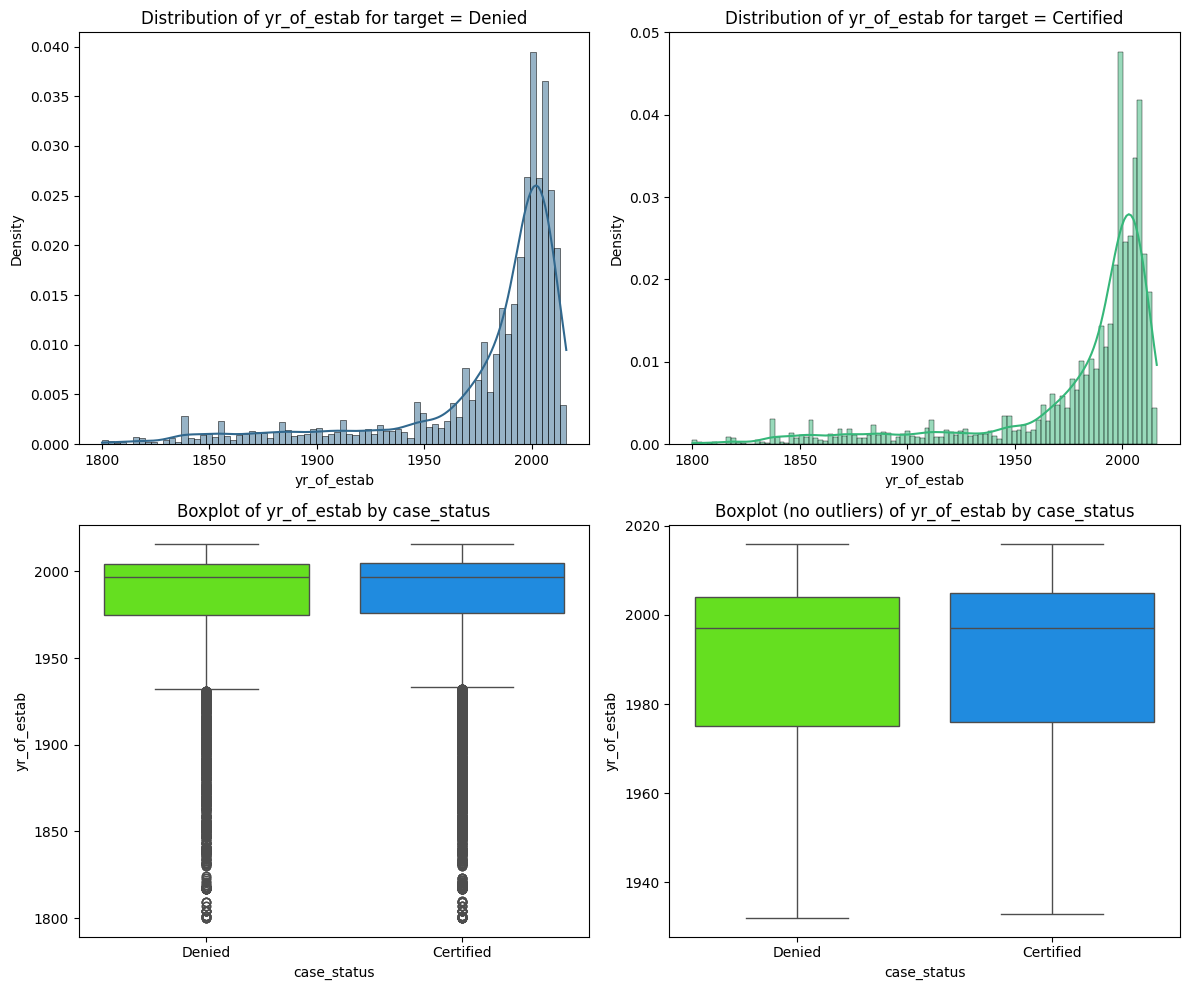

In [37]:
distribution_plot_wrt_target(df, "yr_of_estab", "case_status")

- Year of establishment of the company does not seem to influence visa approval rates as shown by the highly similar and overlapping box plots and histogram distributions of Denied and Certified applications.

### Summary of Observations in Bivariate Analysis

-  The categorical features like education level and job experience, along with continent and region of employment, have a more discernible relationship with visa approval status compared to the numerical features like number of employees (company size), year of establishment (age), and prevailing wage.

# **6. Data Pre-processing**

Data pre-processing may include the following processes depending on the need:
- Missing value treatment
- Outlier detection and treatment
- Feature engineering
- Preparing data for modeling
- Any other preprocessing steps

Based on our Data Overview, there are no missing or duplicated values, so **no missing value treatment is required**.

## **6.1. Outlier Detection and Treatment**


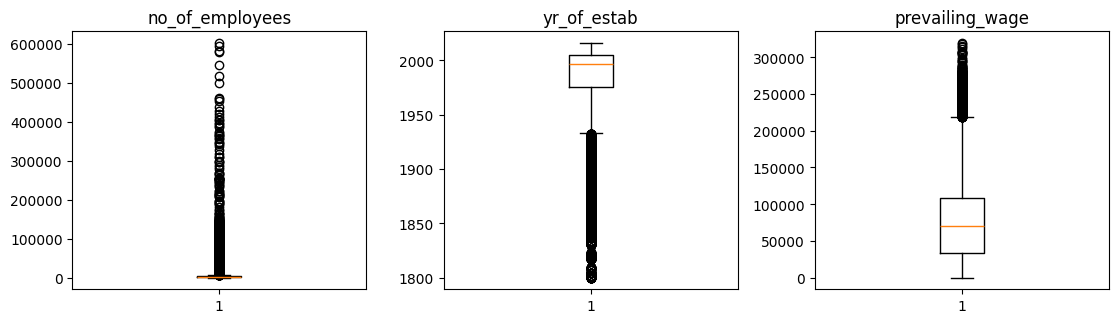

In [ ]:
# Outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Normalizing the Units of Prevailing Wage

 - Note that normalizing the units, e.g., converting the different units of `prevailing_wage` entries into the same kind is not the same as statistical normalization. Hence, handling these preprocessing prior to data splitting will not introduce data leakage.

In [ ]:
df['unit_of_wage'].value_counts()

,count
unit_of_wage,
Year,22962
Hour,2157
Week,272
Month,89


   prevailing_wage unit_of_wage  prevailing_wage_annual
0          592.203         Hour             1231782.032
1        83425.650         Year               83425.650
2       122996.860         Year              122996.860
3        83434.030         Year               83434.030
4       149907.390         Year              149907.390


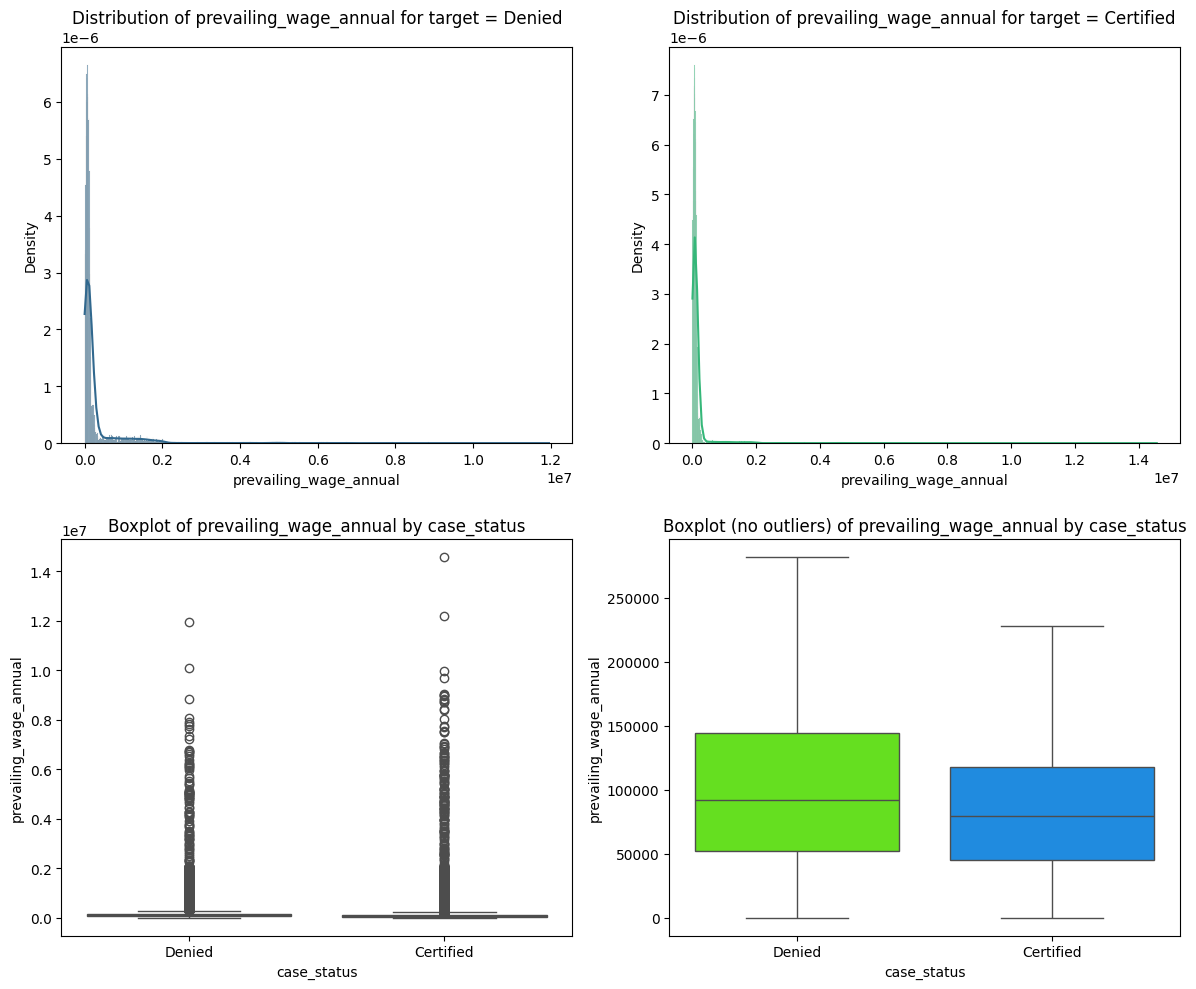

In [ ]:
# Converting all the prevailing wage to annual unit of wage

def convert_wage_to_annual(row):
    """Converts prevailing wage to an annual unit based on the unit_of_wage column."""

    wage = row['prevailing_wage']
    unit = row['unit_of_wage']

    if unit == 'Year':
        return wage
    elif unit == 'Month':
        return wage * 12
    elif unit == 'Week':
        return wage * 52
    elif unit == 'Hour':
        # Assuming a full-time work year of 40 hours/week * 52 weeks/year
        return wage * 40 * 52
    else:
        # Handle unexpected units, maybe return the original wage or NaN
        return wage

# Apply the function to create a new column with annual wage
df['prevailing_wage_annual'] = df.apply(convert_wage_to_annual, axis=1)

# Display the head of the DataFrame with the new column
print(df[['prevailing_wage', 'unit_of_wage', 'prevailing_wage_annual']].head())

# Verify the units are gone if you dropped them
# print(df.head())

# Check the distribution of the new annual wage column
distribution_plot_wrt_target(df, "prevailing_wage_annual", "case_status")


In [ ]:
# Show examples where unit_of_wage is Hourly
print(df[df['unit_of_wage'] == 'Hour'][['prevailing_wage', 'unit_of_wage', 'prevailing_wage_annual']].head())

# Show examples where unit_of_wage is Weekly
print(df[df['unit_of_wage'] == 'Week'][['prevailing_wage', 'unit_of_wage', 'prevailing_wage_annual']].head())

# Show examples where unit_of_wage is Monthly
print(df[df['unit_of_wage'] == 'Month'][['prevailing_wage', 'unit_of_wage', 'prevailing_wage_annual']].head())

# Show examples where unit_of_wage is Annually
print(df[df['unit_of_wage'] == 'Year'][['prevailing_wage', 'unit_of_wage', 'prevailing_wage_annual']].head())


    prevailing_wage unit_of_wage  prevailing_wage_annual
0           592.203         Hour             1231782.032
7           418.230         Hour              869917.984
54          230.807         Hour              480078.976
62          103.222         Hour              214700.928
70          230.327         Hour              479080.160
     prevailing_wage unit_of_wage  prevailing_wage_annual
113        98966.720         Week             5146269.440
116        32400.200         Week             1684810.400
169        71825.630         Week             3734932.760
243        62112.220         Week             3229835.440
365        67492.780         Week             3509624.560
     prevailing_wage unit_of_wage  prevailing_wage_annual
220       141796.390        Month             1701556.680
241        56606.540        Month              679278.480
438        88925.590        Month             1067107.080
498        97931.990        Month             1175183.880
540        82793.800

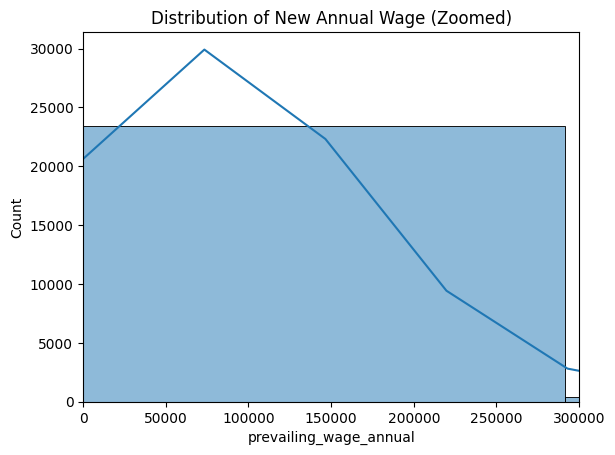

In [ ]:
# Investigating the distribution of prevailing_wage_annual
sns.histplot(df['prevailing_wage_annual'], kde=True, bins=50)
plt.title('Distribution of New Annual Wage (Zoomed)')
plt.ticklabel_format(style='plain', axis='x')
plt.xlim(0, 300000) # Adjust the limit based on where the most density is
plt.show()

In [ ]:
print("Rows with the lowest prevailing_wage_annual values:")
display(df.nsmallest(10, 'prevailing_wage_annual'))

Rows with the lowest prevailing_wage_annual values:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage_annual
12395,Asia,Master's,Y,N,9105,2001,Midwest,100.000,Year,Y,Certified,100.000
21100,Europe,Doctorate,N,N,3752,2013,West,104.170,Year,Y,Certified,104.170
6035,Europe,Bachelor's,Y,N,4406,1999,West,113.960,Year,Y,Certified,113.960
9778,Asia,Master's,Y,N,1503,2001,Northeast,115.810,Year,Y,Certified,115.810
12721,Europe,Bachelor's,Y,N,4310,2010,Midwest,121.650,Year,Y,Certified,121.650
11427,Europe,Master's,N,N,4106,1902,South,126.280,Year,Y,Certified,126.280
18352,Europe,Master's,N,N,1702,1953,West,127.890,Year,Y,Certified,127.890
4684,Europe,Doctorate,Y,N,4315,1868,South,135.170,Year,Y,Certified,135.170
23691,Asia,Bachelor's,Y,N,4017,1999,Midwest,136.510,Year,Y,Certified,136.510
18525,North America,Master's,N,Y,30715,1994,West,140.590,Year,Y,Certified,140.590


- The zoomed-in view of the histogram where density is the highest and the table containing the lowest prevailing_wage_annual shows there are still abnormally low values that was not resolved by normalization into the same unit.
- This could be due to data entry errors.
- We will remove these outliers since they can skew the results of our model.

### Cleaning Prevailing Wage Annual

In [ ]:
# Minimum wage in 2016
# 7.25 USD/hour×40 hours/week×52 weeks/year=15,080 USD/year
min_annual_wage_2016 = 15080

# Flagging rows below minimum wage
df['is_invalid_wage'] = df['prevailing_wage_annual'] < min_annual_wage_2016

# Displaying the flagged records
invalid_wage_df = df[df['is_invalid_wage']]

# Removing invalid records
df1 = df[~df['is_invalid_wage']].copy()

# Dropping the unnecessary columns after cleaning
df1 = df1.drop(['prevailing_wage', 'unit_of_wage', 'is_invalid_wage'], axis=1)

In [ ]:
# Checking the minimum prevailing_wage_annual values in the cleaned dataframe df1
print("Rows with the lowest prevailing_wage_annual values:")
display(df1.nsmallest(10, 'prevailing_wage_annual'))

Rows with the lowest prevailing_wage_annual values:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,prevailing_wage_annual
4285,Asia,Master's,Y,N,82,2006,Northeast,Y,Certified,15082.640
6481,Asia,Doctorate,Y,N,3715,1956,South,Y,Certified,15082.760
4009,Europe,Bachelor's,N,N,4752,1986,West,Y,Certified,15084.770
14075,Asia,Bachelor's,Y,N,5038,1983,South,Y,Certified,15087.180
16623,North America,Master's,Y,N,3723,2014,Midwest,Y,Certified,15091.010
1080,North America,Master's,N,N,12650,1983,Northeast,N,Denied,15103.380
2641,Asia,Master's,N,N,736,1994,South,Y,Denied,15108.150
19844,Europe,Bachelor's,Y,N,2732,1983,South,Y,Certified,15123.820
6898,Asia,Bachelor's,Y,Y,3692,1977,West,Y,Certified,15129.430
15472,Asia,Master's,N,N,1114,2003,Northeast,Y,Denied,15130.240


In [ ]:
print(df.shape[0] - df1.shape[0])

1597


- 1597 erroneous prevailing wage observations were removed.

### Checking Number of Employees

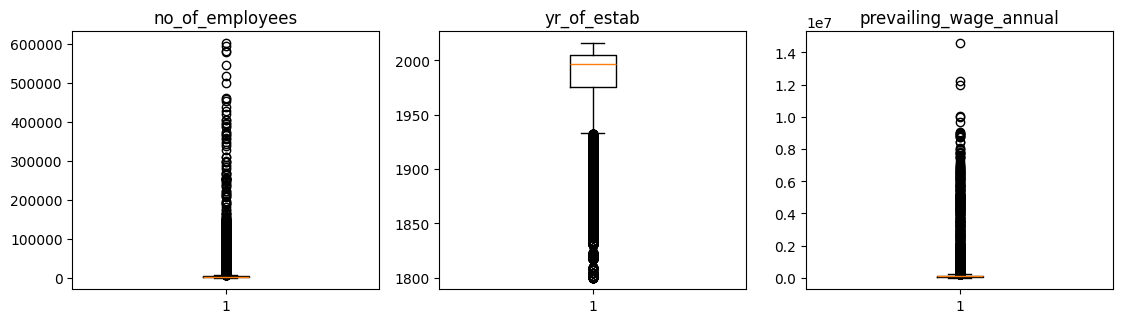

In [ ]:
# Outlier detection using boxplot
numeric_columns = df1.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df1[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [ ]:
# Checking rows with the lowest no_of_employees values
print("Rows with the lowest no_of_employees values:")
display(df1.nsmallest(5, 'no_of_employees'))

Rows with the lowest no_of_employees values:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,prevailing_wage_annual
378,Asia,Bachelor's,N,Y,11,2011,Northeast,Y,Denied,32506.140
7761,Asia,Master's,N,N,11,2009,Midwest,Y,Certified,38457.510
14022,Asia,Bachelor's,N,Y,11,1946,Northeast,Y,Certified,108403.560
14726,Asia,Master's,N,N,11,2000,Midwest,Y,Certified,167851.800
15859,Asia,High School,N,N,11,1969,South,Y,Denied,44640.600


In [ ]:
# Checking rows with the highest no_of_employees values
print("Rows with the highest no_of_employees values:")
display(df1.nlargest(5, 'no_of_employees'))

Rows with the highest no_of_employees values:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,prevailing_wage_annual
21339,North America,Doctorate,Y,N,602069,2011,Northeast,Y,Certified,25181.630
1345,Asia,Bachelor's,N,N,594472,1887,West,Y,Denied,87144.200
20345,Asia,Master's,N,N,581468,1984,Northeast,N,Certified,41397.520
11317,Asia,Master's,N,N,579004,1969,South,N,Certified,103507.010
9587,Asia,Bachelor's,Y,N,547172,1838,Northeast,N,Certified,22859.220


- There very large corporations with more than 500,000 employees. However, there seems to be no error, despite the highly skewed distribution of `no_of_employees`.

## **6.2. Feature Engineering**

### From Year of Establishment to Company Age

We are transforming `year_of_establishment` into a variable that is easier interpret, i.e., `company_age`. This will help us avoid confusing ordinal behavior tied to calendar years.

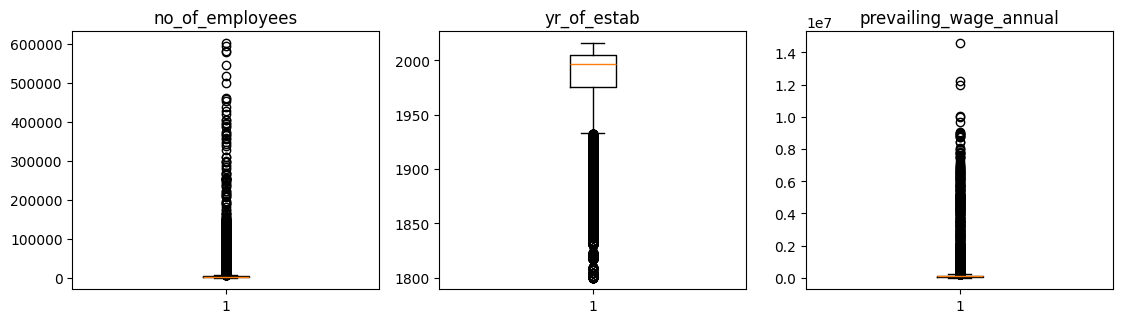

In [ ]:
# Outlier detection using boxplot
numeric_columns = df1.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df1[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [ ]:
# Transforming yr_of_estab into company_age

df1['company_age'] = 2016 - df1['yr_of_estab']
df1.drop(columns=['yr_of_estab'], inplace=True)
df1.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,N,14513,West,Y,Denied,1231782.032,9
1,Asia,Master's,Y,N,2412,Northeast,Y,Certified,83425.650,14
2,Asia,Bachelor's,N,Y,44444,West,Y,Denied,122996.860,8
3,Asia,Bachelor's,N,N,98,West,Y,Denied,83434.030,119
4,Africa,Master's,Y,N,1082,South,Y,Certified,149907.390,11


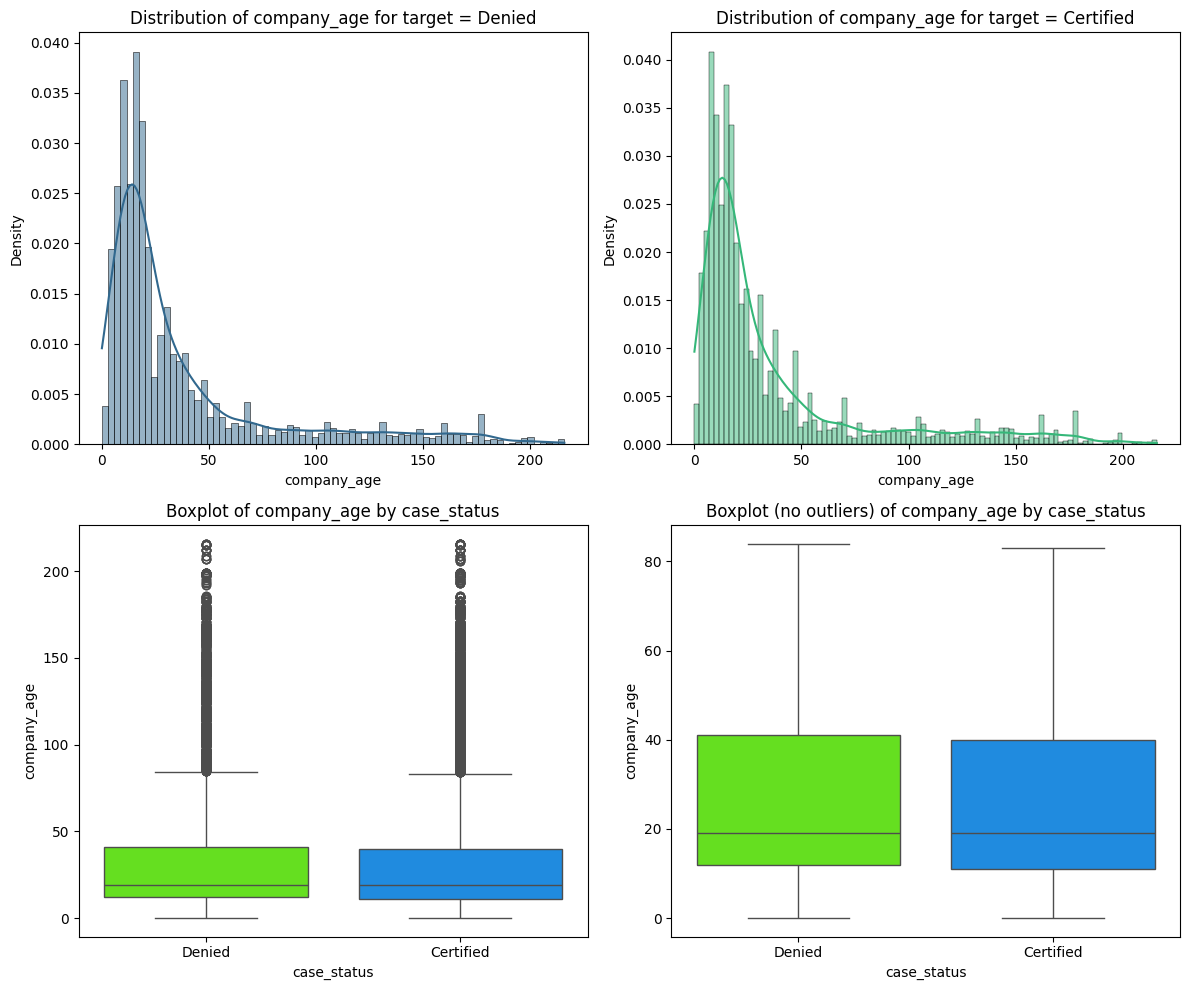

In [ ]:
distribution_plot_wrt_target(df1, "company_age", "case_status")

- Based on my research, there are US companies from the 18th and 19th centuries that are still running today so we will not treat the outliers (e.g., capping, log transformation, or dropping).

## **6.3. Data Preparation for modeling**

- Our goal is to predict which visa will be certified.
- Before building models that require all features to be numeric, we need to encode (one-hot encoding) categorical features.
- Then we will split the data into train and test sets to be able to evaluate each model's generalization capabilities.

### Data Splitting

In [ ]:
# Transforming target variable into numeric data type
df1["case_status"] = df1["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

# Assigning target and feature variables
X = df1.drop(["case_status"], axis=1)
y = df1["case_status"]

# Splitting data into training, validation, and test sets:

# 1. Splitting data into 2 parts: temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# 2. Splitting the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (14329, 9)
Shape of the Validation set:  (4777, 9)
Shape of test set :  (4777, 9)
Percentage of classes in training set:
case_status
1   0.663
0   0.337
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1   0.663
0   0.337
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1   0.663
0   0.337
Name: proportion, dtype: float64


### One-Hot Encoding

To avoid data leakage, we are applying one-hot encoding of the categorical variables after the original dataset has been split into training, validation, and test sets.

In [ ]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# **7. Model Building**

## **7.1.Key Information**

### Evaluation Criterion for the Model

In a visa prediction setting, the model can make two key types of errors:

1. **False Positive**:
  - Predicts that the visa will be certified, but it should be denied.
  - Risk: An unqualified applicant may receive a visa, potentially taking a job that could have gone to a U.S. citizen.

2. **False Negative**:
  - Predicts that the visa will be denied, but it should be certified.
  - Risk: A qualified foreign applicant is rejected, resulting in lost talent that could have contributed to the U.S. economy.

Both errors carry significant consequences. To minimize both risks, we:

- Use the **F1 Score** as the primary evaluation metric to balance precision and recall.

- Apply balanced class weights to ensure the model gives equal attention to both classes

----------------------------------------------------------------

### Modeling Workflow

- Models will be trained on the training set.

- Performance will be evaluated on the validation set to guide model selection and tuning.

- Only the best-performing model will be evaluated on the test set to estimate its final performance.

----------------------------------------------------------------

### Key Concepts Considered
1. **Cross-Validation (CV)**
  - A technique for assessing model generalization by splitting the training data into folds and validating on each fold.
  - Why we use it: Helps avoid overfitting and provides a more robust estimate of model performance.

2. **Grid Search CV vs. Randomized Search CV**

  - Grid Search CV tests all parameter combinations from a predefined grid.

  - Randomized Search CV samples a fixed number of combinations from a wider range.
  
  - Why we use them: They help find optimal hyperparameters to improve model accuracy and generalization. Randomized Search is preferred when we want speed and efficiency.

3. **Oversampling vs. Undersampling**

  - Oversampling boosts the minority class (e.g., Synthethic Minority Oversampling Technique (SMOTE) and Random Under Sampler).

  - Undersampling reduces the majority class size.
  
  - Why we use them: To address class imbalance and improve the model’s ability to correctly identify minority class instances.

4. **Hyperparameter Tuning**

  - The process of adjusting model settings (e.g., learning rate, tree depth) to enhance performance.
  - Why we use it: Well-tuned models generalize better and perform more reliably on unseen data.

----------------------------------------------------------------

### Two Modeling Approaches

We will explore two main modeling approaches to try different ways of building models, compare their results, and find what works best.

- **Modeling Approach 1** focuses on:

  - Selecting the best classification models based on their cross-validation (CV) performance.

  - Then, we apply hyperparameter tuning using both Grid Search CV and Randomized Search CV to see which one gives better results.

- **Modeling Approach 2** looks at:

  - Evaluating the effect of oversampling and undersampling on model performance using the training and validation sets. We pick the top-performing models from this step.

  - Then, we tune the hyperparameters of these models using Randomized Search CV, since it’s faster, less computationally intensive, and often performs just as well (or better) than Grid Search.

- We're exploring these two approaches separately so we can:

  - Understand the individual contribution of resampling techniques versus model choice and tuning.

  - Avoid confounding effects and ensure that any improvement in performance is interpretable and well-justified.

 ## **7.2. Automating Metrics and Confusion Matrix (sklearn library)**

 Before we build models, we will implement reusable functions for metric calculation and confusion matrix plotting:

  * `model_performance_classification_sklearn`: evaluates model performance
  * `confusion_matrix_sklearn`: visualizes the confusion matrix for better error analysis


In [ ]:
# Function to compute different metrics to check performance of a classification model built using sklearn

def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # Predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# Function to plot the confusion matrix of a classification model built using sklearn

def confusion_matrix_sklearn(model, predictors, target):
    """
    Plotting the confusion matrix with percentage annotations

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # Generating predicted labels using the trained model
    y_pred = model.predict(predictors)

    # Computing the confusion matrix (actual vs predicted)
    cm = confusion_matrix(target, y_pred)

    # Creating labels that include both counts and percentages
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    # Plotting the confusion matrix as a heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")  # Adding both count and % in each cell
    plt.ylabel("True label")               # Labeling y-axis as actual values
    plt.xlabel("Predicted label")          # Labeling x-axis as predicted values


# **8. Modeling Approach 1**

## **8.1. Initial Model Building with Cross Validation**

- The code compares classification models using F1 scores from cross-validation on training data and evaluation on a separate validation set.

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# Loop through all models to get the mean cross-validated f1 score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "f1"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 76.57917030263607
Random forest: 78.88441443775463
GBM: 81.42941451322892
Adaboost: 81.28582927928521
Xgboost: 79.96064553273766
dtree: 73.11082773965468

Validation Performance:

Bagging: 0.7681388012618297
Random forest: 0.7930720145852325
GBM: 0.8154788585088899
Adaboost: 0.8109845165059889
Xgboost: 0.7985546522131888
dtree: 0.7324302788844621


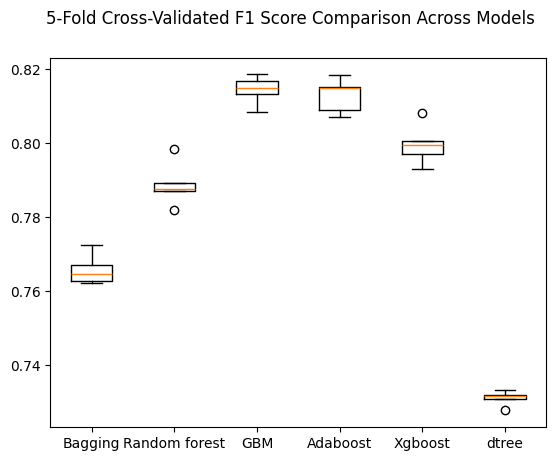

In [ ]:
# Plotting boxplots for CV scores of all models defined above where the number of folds is 5 and the results are based on the training set.
fig = plt.figure()

fig.suptitle("5-Fold Cross-Validated F1 Score Comparison Across Models")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

- Gradient Boosting (GBM) has the highest median F1 score (~0.81) with a narrow, compact boxplot, indicating very consistent performance across CV folds.

- AdaBoost also achieves a high median (~0.81) but shows a slightly wider spread, suggesting more variability in performance compared to GBM.

- XGBoost follows closely with a slightly lower median (~0.80) and moderate spread, still placing it among the top performers.

- Random Forest shows a lower median (~0.79) with a few outliers, indicating inconsistent performance across folds.

- Bagging and Decision Trees perform the worst, with low median scores and high variability, making them less viable for final selection.

- We will proceed to hypertuning the top 3 performing models: **GBM, Adaboost, and XGBoost**.

## **8.2. Hyperparameter Tuning**

- We will tune GBM, Adaboost, and XGBoost models using GridSearchCV and RandomizedSearchCV.
- We will also compare the performance and time taken by these two methods, i.e., GridSearchCV and RandomizedSearchCV.

### Gradient Boost

#### GridSearchCV

In [ ]:
%%time
# Creating pipeline
model = GradientBoostingClassifier(random_state=1)

# Parameter grid for GradientBoostingClassifier
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "subsample": [0.8, 1.0],  # stochastic gradient boosting
}

# Scoring metric
scorer = metrics.make_scorer(metrics.f1_score)

# GridSearchCV
grid_cv_gbm = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fit on training data
grid_cv_gbm.fit(X_train, y_train)

# Create new model with best parameters
gbm_tuned1 = GradientBoostingClassifier(random_state=1, **grid_cv_gbm.best_params_)

# Fit the new model on training data
gbm_tuned1.fit(X_train, y_train)

CPU times: user 35min 49s, sys: 4.18 s, total: 35min 53s
Wall time: 36min 14s


GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=200,
                           random_state=1)

In [ ]:
# Calculating different metrics on train set
gbm_grid_train = model_performance_classification_sklearn(
    gbm_tuned1, X_train, y_train
)
print("Training performance:")
gbm_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.746,0.903,0.759,0.825


In [ ]:
# Calculating different metrics on validation set
gbm_grid_val = model_performance_classification_sklearn(gbm_tuned1, X_val, y_val)
print("Validation performance:")
gbm_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.740,0.890,0.760,0.820


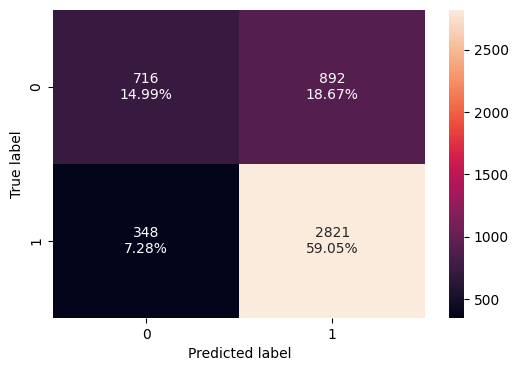

In [ ]:
# Creating confusion matrix
confusion_matrix_sklearn(gbm_tuned1, X_val, y_val)

#### RandomizedSearchCV

In [ ]:
%%time
# Creating pipeline
model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
    "subsample": [0.8, 1.0],
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Calling RandomizedSearchCV
randomized_cv_gbm = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv_gbm.fit(X_train, y_train)

# Creating new pipeline with best parameters
gbm_tuned2 = GradientBoostingClassifier(random_state=1, **randomized_cv_gbm.best_params_)

# Fit the model on training data
gbm_tuned2.fit(X_train, y_train)

CPU times: user 5min 36s, sys: 632 ms, total: 5min 36s
Wall time: 5min 39s


GradientBoostingClassifier(learning_rate=0.01, max_depth=6, min_samples_split=5,
                           random_state=1, subsample=0.8)

In [ ]:
# Calculating different metrics on train set
gbm_random_train = model_performance_classification_sklearn(
    gbm_tuned2, X_train, y_train
)
print("Training performance:")
gbm_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.746,0.952,0.740,0.833


In [ ]:
# Calculating different metrics on validation set
gbm_random_val = model_performance_classification_sklearn(gbm_tuned2, X_val, y_val)
print("Validation performance:")
gbm_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.723,0.933,0.727,0.817


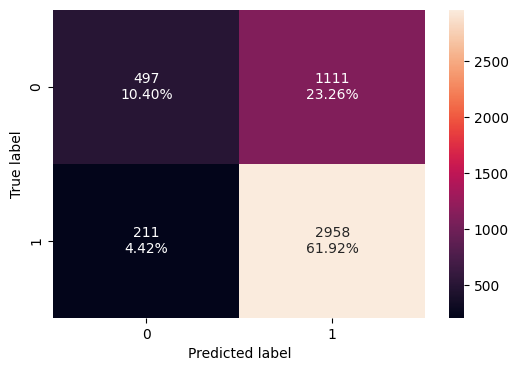

In [ ]:
# Creating confusion matrix
confusion_matrix_sklearn(gbm_tuned2, X_val, y_val)

#### Analysis

- GridSearchCV achieved a validation F1 score of 0.820, with well-balanced precision (0.760) and recall (0.890), indicating strong and consistent performance. The training F1 score (0.825) further suggests good generalization without overfitting.

- In contrast, RandomizedSearchCV delivered a slightly lower validation F1 score (0.817) but with a different balance: higher recall (0.933) and lower precision (0.727), favoring fewer false negatives at the expense of more false positives. Its training F1 score (0.833) was marginally higher, though with signs of more variability.

- The key difference is in runtime. GridSearchCV took ~36 minutes, while RandomizedSearchCV ran in just ~6 minutes, offering nearly equivalent F1 performance with significantly lower computational cost.

### AdaBoost

#### GridSearchCV

In [ ]:
%%time
# Creating pipeline
model = AdaBoostClassifier(random_state=1)

# Parameter grid for GradientBoostingClassifier
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
}

# Scoring metric
scorer = metrics.make_scorer(metrics.f1_score)

# GridSearchCV
grid_cv_abc = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fit on training data
grid_cv_abc.fit(X_train, y_train)

# Create and train new model with best parameters
abc_tuned1 = AdaBoostClassifier(random_state=1, **grid_cv_abc.best_params_)
abc_tuned1.fit(X_train, y_train)

CPU times: user 1min 2s, sys: 158 ms, total: 1min 2s
Wall time: 1min 3s


AdaBoostClassifier(random_state=1)

In [ ]:
# Calculating different metrics on train set
abc_grid_train = model_performance_classification_sklearn(
    abc_tuned1, X_train, y_train
)
print("Training performance:")
abc_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.733,0.881,0.756,0.814


In [ ]:
# Calculating different metrics on validation set
abc_grid_val = model_performance_classification_sklearn(abc_tuned1, X_val, y_val)
print("Validation performance:")
abc_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.729,0.876,0.755,0.811


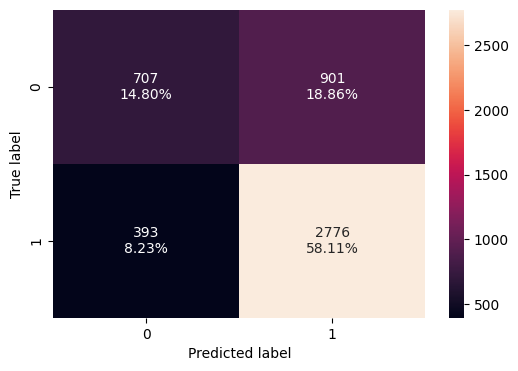

In [ ]:
# Creating confusion matrix
confusion_matrix_sklearn(abc_tuned1, X_val, y_val)

#### RandomizedSearchCV

In [ ]:
%%time
# Creating pipeline
model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Calling RandomizedSearchCV
randomized_cv_abc = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv_abc.fit(X_train, y_train)

# Creating new pipeline with best parameters
abc_tuned2 = AdaBoostClassifier(random_state=1, **randomized_cv_abc.best_params_)

# Fit the model on training data
abc_tuned2.fit(X_train, y_train)

CPU times: user 3min 10s, sys: 462 ms, total: 3min 10s
Wall time: 3min 12s


AdaBoostClassifier(random_state=1)

In [ ]:
# Calculating different metrics on train set
abc_random_train = model_performance_classification_sklearn(
    abc_tuned2, X_train, y_train
)
print("Training performance:")
abc_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.733,0.881,0.756,0.814


In [ ]:
# Calculating different metrics on validation set
abc_random_val = model_performance_classification_sklearn(abc_tuned2, X_val, y_val)
print("Validation performance:")
abc_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.729,0.876,0.755,0.811


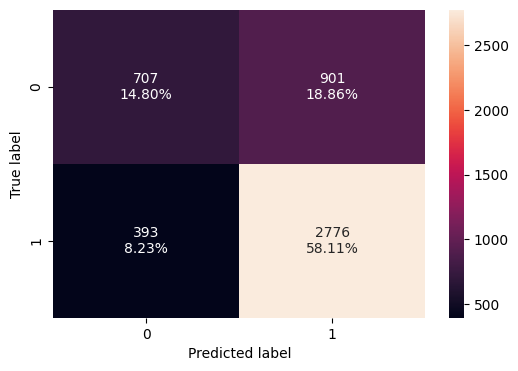

In [ ]:
# Creating confusion matrix
confusion_matrix_sklearn(abc_tuned2, X_val, y_val)

#### Analysis

- Both GridSearchCV and RandomizedSearchCV produced identical results for AdaBoost, with a validation F1 score of 0.811. The model showed a balanced trade-off between precision (0.755) and recall (0.876), effectively minimizing both false positives and false negatives. The training F1 score (0.814) matched closely, indicating consistent generalization and no signs of overfitting.

- What differentiates the two is runtime efficiency. Despite using a smaller hyperparameter grid (only 2 parameters with 3 values each), GridSearchCV completed in ~1 minute, while RandomizedSearchCV took ~3 minutes. This is likely due to RandomizedSearchCV randomly sampling more combinations than necessary for such a small search space.

- In this case, GridSearchCV is both faster and sufficient, given the limited parameter set and equivalent performance.

### XGBoost

#### GridSearchCV

In [ ]:
%%time
#defining model
model = XGBClassifier(random_state=1,eval_metric='logloss')

#Parameter grid to pass in GridSearchCV
param_grid={'n_estimators':np.arange(50,150,50),
            'scale_pos_weight':[2,5,10],
            'learning_rate':[0.01,0.1,0.2,0.05],
            'gamma':[0,1,3,5],
            'subsample':[0.8,0.9,1],
            'max_depth':np.arange(1,5,1),
            'reg_lambda':[5,10]}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling GridSearchCV
grid_cv_xg = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

#Fitting parameters in GridSeachCV
grid_cv_xg.fit(X_train,y_train)

# Create and train new model with best parameters
xgb_tuned1 = XGBClassifier(random_state=1, **grid_cv_xg.best_params_)
xgb_tuned1.fit(X_train, y_train)

CPU times: user 52min 31s, sys: 24.7 s, total: 52min 56s
Wall time: 30min 59s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(4), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(100), n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
# Calculating different metrics on train set
xgboost_grid_train = model_performance_classification_sklearn(
    xgb_tuned1, X_train, y_train
)
print("Training performance:")
xgboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.740,0.970,0.728,0.832


In [ ]:
# Calculating different metrics on validation set
xgboost_grid_val = model_performance_classification_sklearn(xgb_tuned1, X_val, y_val)
print("Validation performance:")
xgboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.713,0.952,0.712,0.815


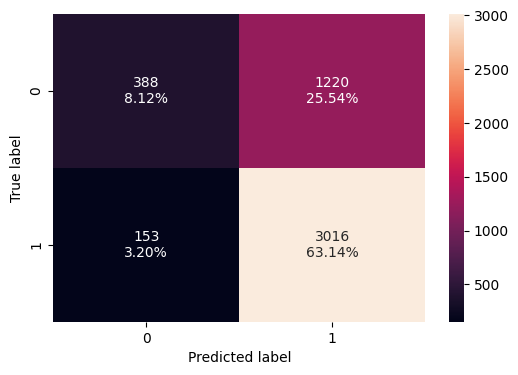

In [ ]:
# Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned1, X_val, y_val)

#### RandomizedSearchCV

In [ ]:
%%time
# defining model
model = XGBClassifier(random_state=1,eval_metric='logloss')

# Parameter grid to pass in RandomizedSearchCV
param_grid={'n_estimators':np.arange(50,150,50),
            'scale_pos_weight':[2,5,10],
            'learning_rate':[0.01,0.1,0.2,0.05],
            'gamma':[0,1,3,5],
            'subsample':[0.8,0.9,1],
            'max_depth':np.arange(1,5,1),
            'reg_lambda':[5,10]}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv_xg = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv_xg.fit(X_train,y_train)

# Create and train new model with best parameters
xgb_tuned2 = XGBClassifier(random_state=1, **randomized_cv_xg.best_params_)
xgb_tuned2.fit(X_train, y_train)

CPU times: user 1min 5s, sys: 507 ms, total: 1min 6s
Wall time: 38.5 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=3, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(3), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(50), n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
# Calculating different metrics on train set
xgboost_random_train = model_performance_classification_sklearn(
    xgb_tuned2, X_train, y_train
)
print("Training performance:")
xgboost_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.663,1.000,0.663,0.798


In [ ]:
# Calculating different metrics on validation set
xgboost_random_val = model_performance_classification_sklearn(xgb_tuned2, X_val, y_val)
print("Validation performance:")
xgboost_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.663,1.000,0.663,0.798


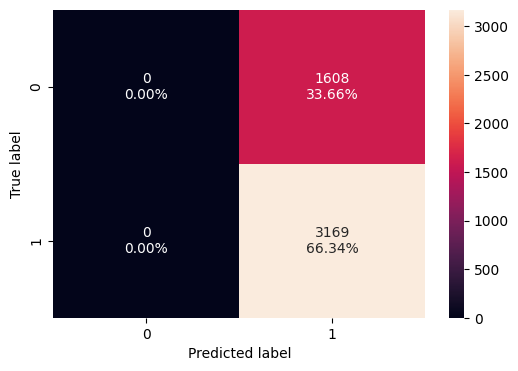

In [ ]:
# Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned2, X_val, y_val)

#### Analysis

- With XGBoost, the contrast between GridSearchCV and RandomizedSearchCV is even more pronounced in both performance and resource usage.

- GridSearchCV delivered a validation F1 score of 0.815, with strong recall (0.952) and reasonable precision (0.712), indicating a well-balanced model that captures most positives without an excessive number of false alarms. The training F1 score was 0.832, showing good generalization. This tuning involved an extensive grid of 7 hyperparameters and required ~53 minutes of CPU time (user + sys), with a wall time of ~31 minutes, reflecting heavy parallelization and computational load.

- In contrast, RandomizedSearchCV completed tuning in just ~1 minute of CPU time and ~38 seconds of wall time, making it far more efficient. However, it produced a noticeably weaker model, with a validation F1 score of 0.798. Although recall was perfect (1.000), precision dropped to 0.663, leading to more false positives. The exact match between training and validation scores (F1 = 0.798) suggests that the model is likely overemphasizing recall at the expense of precision, possibly due to suboptimal hyperparameter selection.

## **8.3. Approach 1: Model Comparison and Final Model Selection**

### Comparing models from GridsearchCV and RandomisedsearchCV

In [ ]:
# Training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm_grid_train.T,
        gbm_random_train.T,
        abc_grid_train.T,
        abc_random_train.T,
        xgboost_grid_train.T,
        xgboost_random_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boost Tuned with Grid search",
    "Gradient Boost Tuned with Random search",
    "AdaBoost Tuned with Grid search",
    "AdaBoost Boost Tuned with Random search",
    "XGBoost Tuned with Grid search",
    "XGBoost Tuned with Random Search",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boost Tuned with Grid search,Gradient Boost Tuned with Random search,AdaBoost Tuned with Grid search,AdaBoost Boost Tuned with Random search,XGBoost Tuned with Grid search,XGBoost Tuned with Random Search
Accuracy,0.746,0.746,0.733,0.733,0.740,0.663
Recall,0.903,0.952,0.881,0.881,0.970,1.000
Precision,0.759,0.740,0.756,0.756,0.728,0.663
F1,0.825,0.833,0.814,0.814,0.832,0.798


In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        gbm_grid_val.T,
        gbm_random_val.T,
        abc_grid_val.T,
        abc_random_val.T,
        xgboost_grid_val.T,
        xgboost_random_val.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boost Tuned with Grid search",
    "Gradient Boost Tuned with Random search",
    "AdaBoost Tuned with Grid search",
    "AdaBoost Boost Tuned with Random search",
    "XGBoost Tuned with Grid search",
    "XGBoost Tuned with Random Search",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boost Tuned with Grid search,Gradient Boost Tuned with Random search,AdaBoost Tuned with Grid search,AdaBoost Boost Tuned with Random search,XGBoost Tuned with Grid search,XGBoost Tuned with Random Search
Accuracy,0.740,0.723,0.729,0.729,0.713,0.663
Recall,0.890,0.933,0.876,0.876,0.952,1.000
Precision,0.760,0.727,0.755,0.755,0.712,0.663
F1,0.820,0.817,0.811,0.811,0.815,0.798


- Among all models and tuning strategies evaluated, Gradient Boosting (GBM) with GridSearchCV is the best performer.  It achieved the highest validation F1 score of 0.820 with a strong balance between precision (0.760) and recall (0.890). Its training F1 score (0.825) closely matched validation, indicating strong generalization with no signs of overfitting. This makes it the most reliable model for minimizing both false positives and false negatives—critical in the visa approval context.

- GBM with RandomizedSearchCV was a close second, with a validation F1 score of 0.817. It achieved higher recall (0.933) but at the cost of lower precision (0.727), increasing the risk of false positives. While it also generalized well (training F1 = 0.833), the drop in precision suggests a less stable balance.

- In comparison, XGBoost with GridSearchCV delivered a slightly lower F1 score (0.815) and lower precision, while RandomizedSearchCV-tuned models—especially XGBoost—showed signs of imbalance, favoring recall too heavily and producing more false positives.

- Overall, GBM with GridSearchCV provides the best combination of F1 performance, balanced error trade-offs, and generalization, making it the top choice for this visa prediction task.

### Best model performance on test set

In [ ]:
Model_test = model_performance_classification_sklearn(gbm_tuned1, X_test, y_test)
Model_test

,Accuracy,Recall,Precision,F1
0,0.734,0.897,0.751,0.817


- On the unseen test set, the tuned Gradient Boosting model maintained strong performance with an F1 score of 0.817, consistent with validation results—indicating excellent generalization.

### Important features of the final model

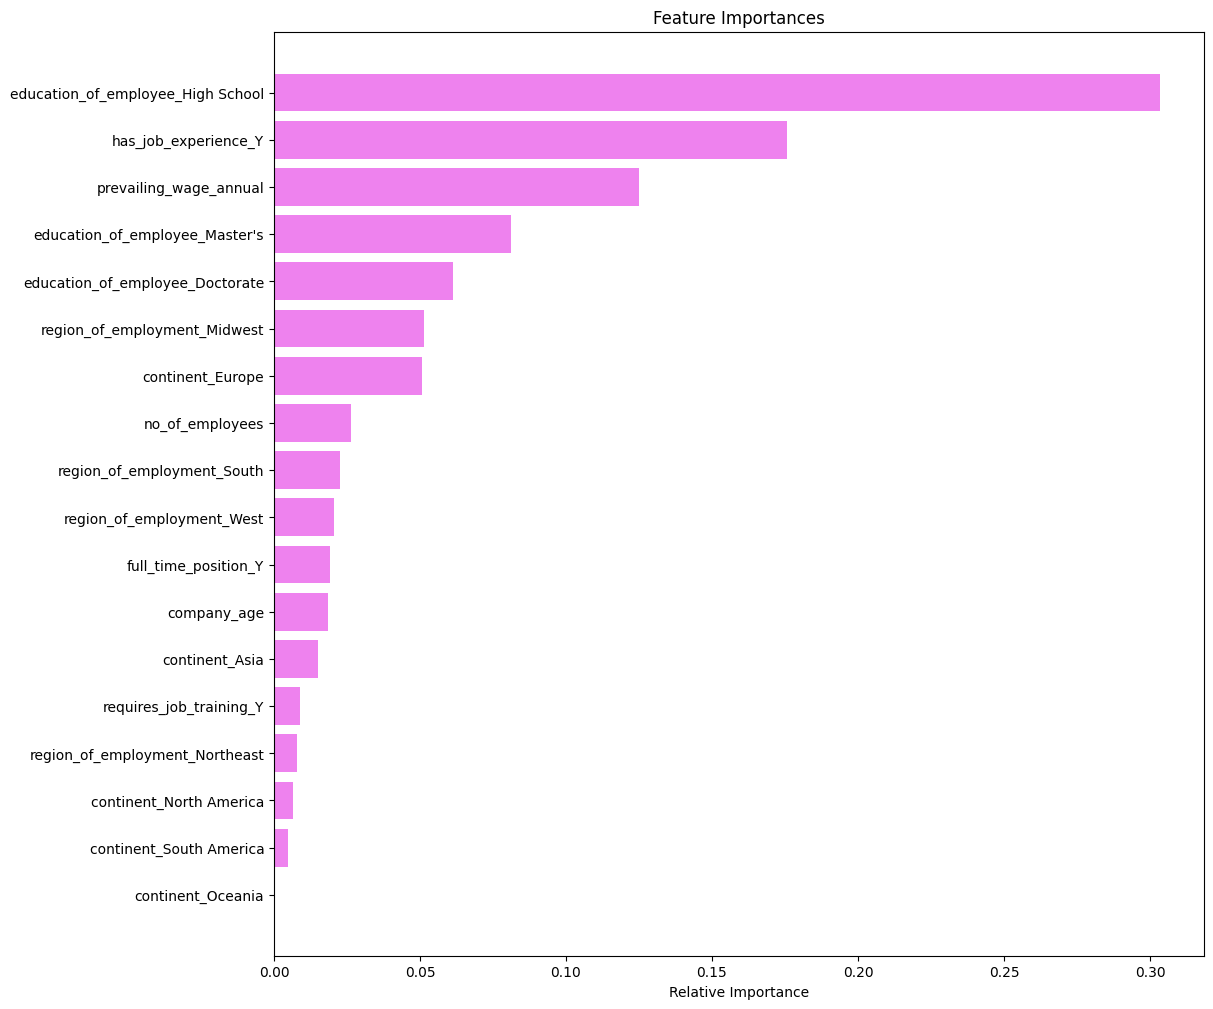

In [ ]:
feature_names = X_train.columns
importances = gbm_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- According to the Gradient Boosting model tuned with GridSearchCV, education level stands out as the most impactful factor—particularly for applicants whose highest qualification is high school. These applicants appear to be significantly less likely to receive visa approval.

- Job experience is another key driver. Individuals with prior work experience are more likely to be certified, reinforcing the importance of demonstrated capability in the workforce.

- The prevailing annual wage offered also plays a strong role. Higher wages—those aligned with or above market standards—are linked to better approval chances.

- Other influential features include holding an advanced degree (such as a Master's or Doctorate) and seeking employment in the Midwest region, both of which are associated with higher certification rates, though their effects are somewhat less pronounced.

- Overall, this model suggests that educational background, work experience, and wage competitiveness are among the most critical factors influencing visa decisions.

# **9. Modeling Approach 2**

## **9.1. Resampling**

### Model Building - Original Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9888185654008439
Random Forest: 1.0
Adaboost: 0.8139150714216306
GBM: 0.821142234979709
Xgboost: 0.8939773524401242
Decision Tree: 1.0

Validation Performance:

Bagging: 0.7681388012618297
Random Forest: 0.7965667821111279
Adaboost: 0.8109845165059889
GBM: 0.8154788585088899
Xgboost: 0.7985546522131888
Decision Tree: 0.7324302788844621


### Model Building - Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 9505
Before Oversampling, counts of label 'Denied': 4824 

After Oversampling, counts of label 'Certified': 9505
After Oversampling, counts of label 'Denied': 9505 

After Oversampling, the shape of train_X: (19010, 18)
After Oversampling, the shape of train_y: (19010,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9865243354647784
Random Forest: 1.0
Adaboost: 0.7857281742173828
GBM: 0.8027413587604291
Xgboost: 0.8711650290755966
Decision Tree: 1.0

Validation Performance:

Bagging: 0.7536184745487071
Random Forest: 0.7882806476484194
Adaboost: 0.8062528182774689
GBM: 0.8118451025056947
Xgboost: 0.7982389555184454
Decision Tree: 0.7299968122409946


### Model Building - Undersampled Data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 9505
Before Under Sampling, counts of label 'Denied': 4824 

After Under Sampling, counts of label 'Certified': 4824
After Under Sampling, counts of label 'Denied': 4824 

After Under Sampling, the shape of train_X: (9648, 18)
After Under Sampling, the shape of train_y: (9648,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9769982144732696
Random Forest: 1.0
Adaboost: 0.6887829151980095
GBM: 0.7173734046932895
Xgboost: 0.8696825067441378
Decision Tree: 1.0

Validation Performance:

Bagging: 0.6945244956772334
Random Forest: 0.7271142109851787
Adaboost: 0.7381075047226515
GBM: 0.7531806615776081
Xgboost: 0.7403730960123225
Decision Tree: 0.6911250873515025


### Analysis

- Based on the results above, neither oversampling nor undersampling improved the f1 scores of the classification models.

- Oversampling (like SMOTE) can introduce synthetic examples that may be noisy or not representative of the real minority class. Meanwhile, undersampling reduces the size of the majority class, which can discard useful information and reduce the model’s ability to learn.

- In this case, undersampling led to the worst results, likely due to lost information.

- Thus, we are proceeding with the Original dataset, which showed the best results.

- In this second approach, we are using randomizedsearchCV to hypertune our models instead of GridSearchCV for computational and time efficiency.



## **9.2. Hyperparamter Tuning**

### Random Forest

In [ ]:
%%time
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True)

parameters = {
    "max_depth": list(np.arange(5, 15, 5)),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [3, 5, 7],
    "n_estimators": np.arange(10, 40, 10),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the randomized search with CV
rand_obj = RandomizedSearchCV(rf_tuned, parameters, scoring=acc_scorer, cv=5)
rand_obj = rand_obj.fit(X_train, y_train) # Chose X_train & y_train vs X_train_over & y_train_over due to best results

# Set the clf to the best combination of parameters
rf_tuned = rand_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

CPU times: user 12.7 s, sys: 20 ms, total: 12.7 s
Wall time: 12.8 s


RandomForestClassifier(max_depth=np.int64(10), max_features='log2',
                       min_samples_split=5, n_estimators=np.int64(30),
                       oob_score=True, random_state=1)

#### Model performance on training set

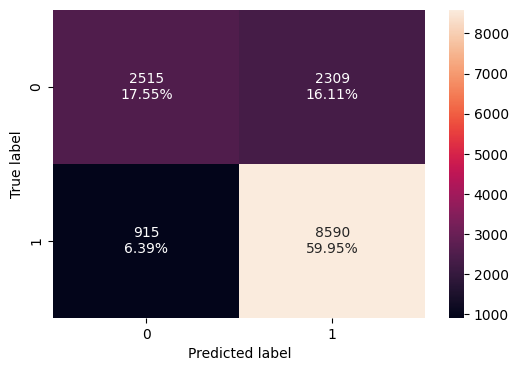

In [ ]:
confusion_matrix_sklearn(rf_tuned, X_train, y_train)

In [ ]:
rf_tuned_model_train_perf = model_performance_classification_sklearn(
    rf_tuned, X_train, y_train
)
rf_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.775,0.904,0.788,0.842


#### Model performance on validation set

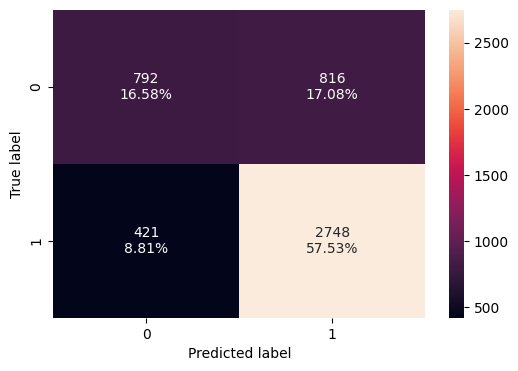

In [ ]:
confusion_matrix_sklearn(rf_tuned, X_val, y_val)

In [ ]:
rf_tuned_model_val_perf = model_performance_classification_sklearn(
    rf_tuned, X_val, y_val
)
rf_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.741,0.867,0.771,0.816


### AdaBoost Classifier

In [ ]:
%%time
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    # Let's try different max_depth for base_estimator
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": np.arange(0.01,0.1,0.05),
}

# Type of scoring used to compare parameter  combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the randomized search with CV
rand_obj = RandomizedSearchCV(abc_tuned, parameters, scoring=acc_scorer, cv=5)
rand_obj = rand_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = rand_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

CPU times: user 1min 21s, sys: 162 ms, total: 1min 21s
Wall time: 1min 22s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=np.float64(0.060000000000000005),
                   n_estimators=np.int64(75), random_state=1)

#### Model performance on training set

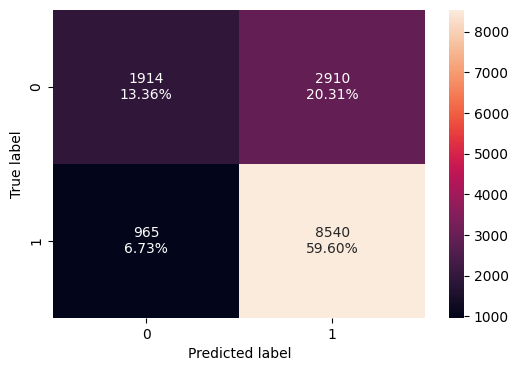

In [ ]:
confusion_matrix_sklearn(abc_tuned, X_train, y_train)

In [ ]:
abc_tuned_model_train_perf = model_performance_classification_sklearn(abc_tuned, X_train, y_train)
abc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.730,0.898,0.746,0.815


#### Model performance on validation set

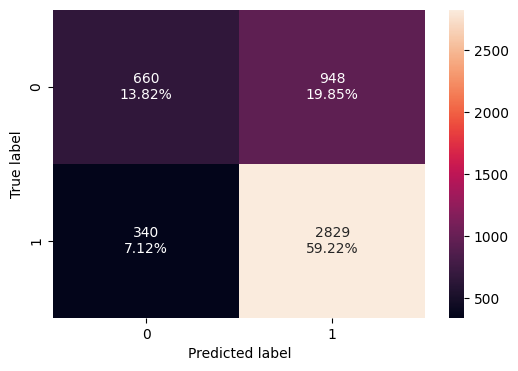

In [ ]:
confusion_matrix_sklearn(abc_tuned, X_val, y_val)

In [ ]:
abc_tuned_model_val_perf = model_performance_classification_sklearn(abc_tuned, X_val, y_val)
abc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.730,0.893,0.749,0.815


### Gradient Boosting Classifier

In [ ]:
%%time
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "subsample": [0.7,0.9],
    "max_features": [0.7, 0.8, 0.9, 1],
    "learning_rate": [0.01,0.1,0.05],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the randmomized search with CV
rand_obj = RandomizedSearchCV(gbc_tuned, parameters, scoring=acc_scorer, cv=5)
rand_obj = rand_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = rand_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

CPU times: user 1min 22s, sys: 198 ms, total: 1min 22s
Wall time: 1min 26s


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.9,
                           n_estimators=np.int64(75), random_state=1,
                           subsample=0.9)

#### Model performance on training set

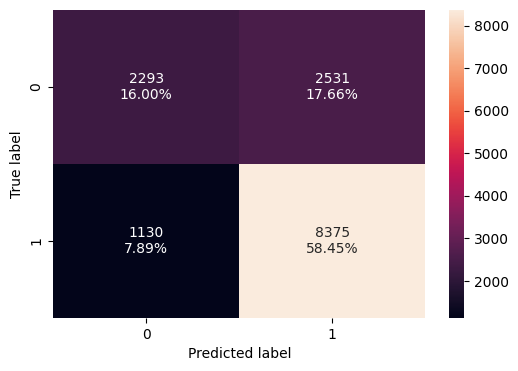

In [ ]:
confusion_matrix_sklearn(gbc_tuned, X_train, y_train)

In [ ]:
gbc_tuned_model_train_perf = model_performance_classification_sklearn(gbc_tuned, X_train, y_train)
gbc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.745,0.881,0.768,0.821


#### Model performance on validation set

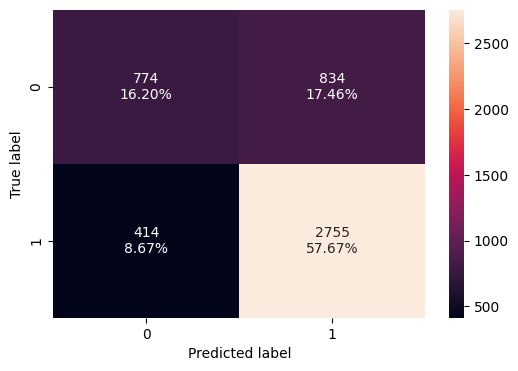

In [ ]:
confusion_matrix_sklearn(gbc_tuned, X_val, y_val)

In [ ]:
gbc_tuned_model_val_perf = model_performance_classification_sklearn(gbc_tuned, X_val, y_val)
gbc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.739,0.869,0.768,0.815


### XGBoost Classifier

In [ ]:
%%time
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1, eval_metric="logloss")

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "scale_pos_weight": [1,2,5],
    "subsample": [0.9, 1],
    "learning_rate": [0.01,0.1,0.05],
    "gamma": [1,3]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the randomized search with CV
rand_obj = RandomizedSearchCV(xgb_tuned, parameters, scoring=acc_scorer, cv=5)
rand_obj = rand_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
xgb_tuned = rand_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

CPU times: user 40.8 s, sys: 248 ms, total: 41.1 s
Wall time: 31.7 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None,
              n_estimators=np.int64(100), n_jobs=None, num_parallel_tree=None,
              random_state=1, ...)

#### Model performance on training set

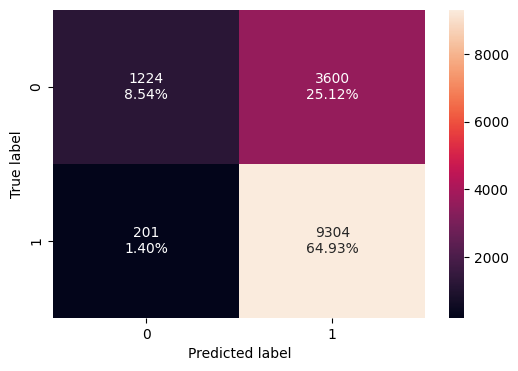

In [ ]:
confusion_matrix_sklearn(xgb_tuned, X_train, y_train)

In [ ]:
xgb_tuned_model_train_perf = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.735,0.979,0.721,0.830


#### Model performance on validation set

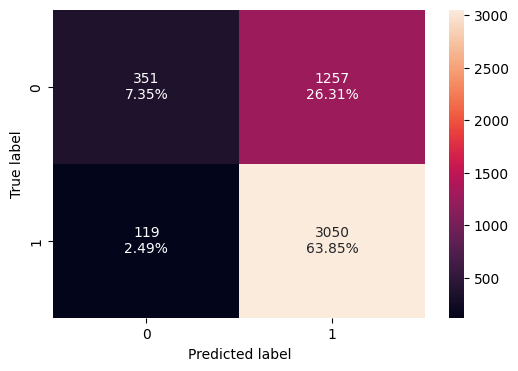

In [ ]:
confusion_matrix_sklearn(xgb_tuned, X_val, y_val)

In [ ]:
xgb_tuned_model_val_perf = model_performance_classification_sklearn(xgb_tuned, X_val, y_val)
xgb_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.712,0.962,0.708,0.816


## **9.3. Analysis of Models in Approach 2**

- Random Forest delivered strong, balanced performance, with relatively high precision (0.771) and recall (0.867) in the validation set. The training-validation F1 gap of 0.026 is modest, indicating mild overfitting, but still within acceptable bounds. The model generalized well and ran very efficiently (with a wall time of ~13 seconds, which is the second fastest).

- AdaBoost showed excellent generalization, with identical training and validation F1 scores (0.815), which is a sign of no overfitting. It leaned slightly more toward recall (0.893 recall vs 0.749 precision in the validation set), effectively capturing most positive cases while maintaining reasonable precision. However, it took the longest time to run with a wall time of ~1.5 minutes.

- Gradient Boosting matched Random Forest in validation F1 (0.816) but offered slightly better training-validation consistency (gap of just 0.002). Its precision and recall were well-balanced (0.772 precision vs 0.864 recall in valdidation set), showing excellent generalization and minimal overfitting. However, this model took the longest time to run with a wall time of ~1.5 minutes.

- XGBoost achieved the highest validation recall (0.947) and F1 score (0.817)among all models in this approach. In addition, this model achieved the most computationally efficient with a wall time of ~32 seconds. However, this came at the cost of lower precision (0.719), meaning it flagged more false positives. The training-validation F1 gap of 0.027—driven by an especially high training recall—suggests mild overfitting.


## **9.4. Approach 2: Model Comparison and Final Model Selection**

### Comparing hypertuned models

In [ ]:
# Training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_tuned_model_train_perf.T,
        abc_tuned_model_train_perf.T,
        gbc_tuned_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned Adaboost Classifier",
    "Tuned Gradient Boost Classifier",
    "Tuned XGBoost Classifier",
]
print("Training set performance comparison:")
models_train_comp_df

Training set performance comparison:


,Tuned Random Forest,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,Tuned XGBoost Classifier
Accuracy,0.775,0.730,0.745,0.735
Recall,0.904,0.898,0.881,0.979
Precision,0.788,0.746,0.768,0.721
F1,0.842,0.815,0.821,0.830


In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        rf_tuned_model_val_perf.T,
        abc_tuned_model_val_perf.T,
        gbc_tuned_model_val_perf.T,
        xgb_tuned_model_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned Adaboost Classifier",
    "Tuned Gradient Boost Classifier",
    "Tuned XGBoost Classifier",
]
print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Tuned Random Forest,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,Tuned XGBoost Classifier
Accuracy,0.741,0.730,0.739,0.712
Recall,0.867,0.893,0.869,0.962
Precision,0.771,0.749,0.768,0.708
F1,0.816,0.815,0.815,0.816


**Which is the best model in our second approach?**

- Since the F1 scores of the our hypertuned models are nearly identical, selecting the best model could not be based purely on this metric. Let's evaluate the most critical factors to consider in selecting the best model for EasyVisa's business problem:
  1. Visa decisions must be consistent and auditable, so a model that generalizes well (i.e., minimal gap between training and validation) is a priority. Gradient Boosting and AdaBoost had negligible to zero overfitting.
  2. Between Precision and Recall, the former is more important since the OFLC prioritizes protecting U.S. jobs and minimizing false approvals. In this case, Gradient Boosting and Randorm Forest are better than XGBoost, which has a lower precision but very high recall.
  3. If computational resources are limited and the model will be used on hundreds of thousands to millions of applications in real time, the model with the shortest runtime would be ideal, such as XGBoost and Random Forest.

- Considering generalization, stability, and precision vs recall trade-off, the Gradient Boosting is the best model in our second approach with negligible overfitting (0.002 difference between training and validation F1 score), and top-tier scores in the validation set, i.e., F1 = 0.816, precision = 0.772, recall = 0.864. However, it is on the longer running end with a wall time of ~1.5 minutes.

### Best model performance on test set



In [ ]:
Model_test = model_performance_classification_sklearn(gbc_tuned, X_test, y_test)
Model_test

,Accuracy,Recall,Precision,F1
0,0.737,0.877,0.762,0.816


### Important features of the final model

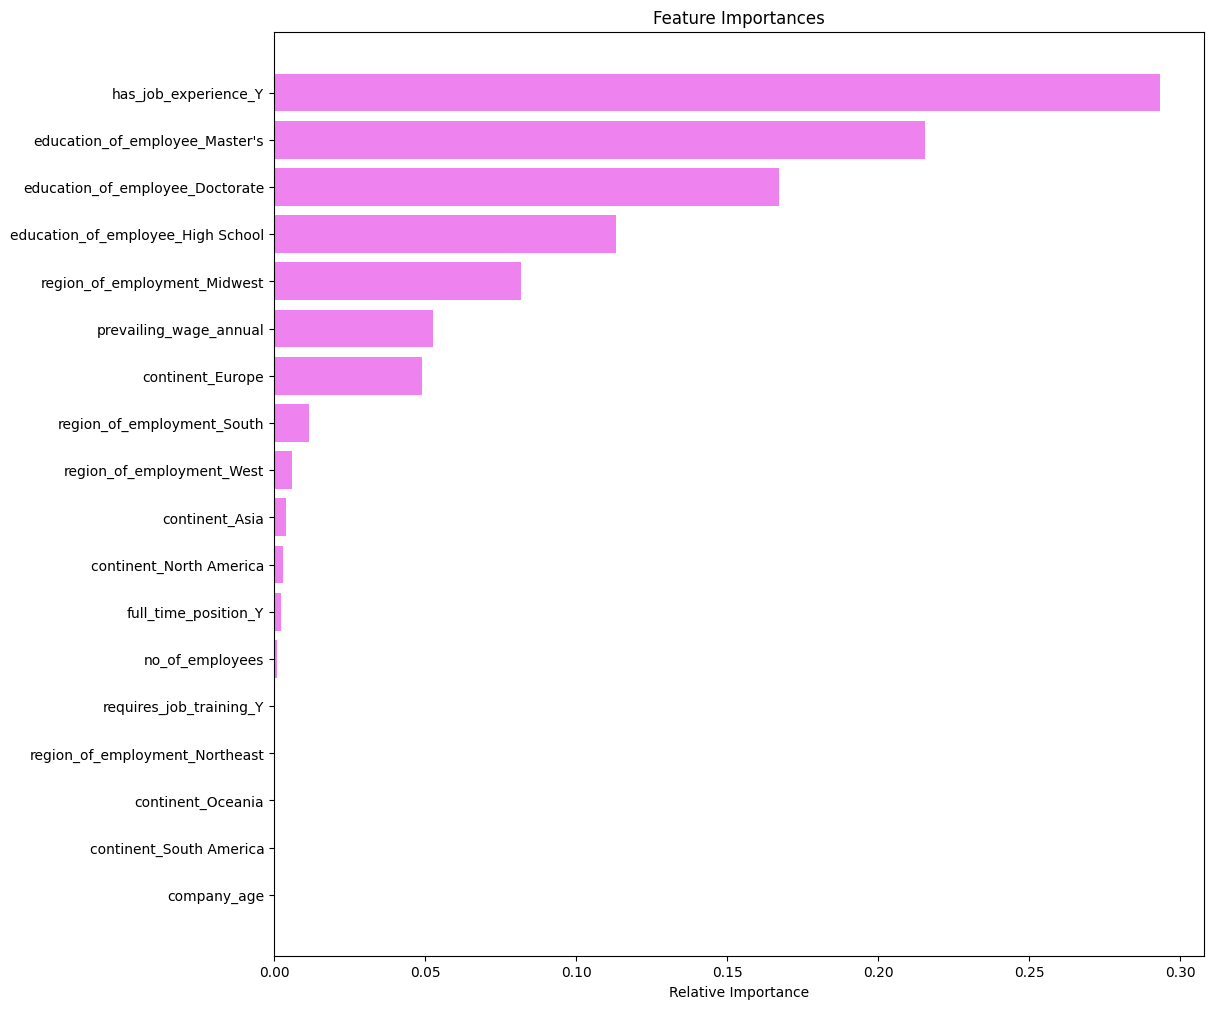

In [ ]:
feature_names = X_train.columns
importances = abc_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- The most important features identified by the Gradient Boosting model tuned via RandomizedSearchCV are:

- The Gradient Boosting model tuned with RandomizedSearchCV shows that job experience is the most influential factor—applicants with prior work experience are much more likely to have their visas approved.

- Educational background also plays a significant role. Those with Master’s or Doctorate degrees tend to have higher approval chances, while applicants whose highest level of education is high school are less likely to be certified.

- Regional trends also emerge. Visa applications tied to employment in the Midwest region appear to have a better chance of approval compared to other regions.

- Another key factor is the prevailing annual wage. Higher wage offers—those that meet or exceed market standards—are associated with greater approval likelihood.

- Lastly, continent of origin seems to matter. Applicants from Europe, in particular, show relatively higher approval trends compared to other regions.

- In summary, this model indicates that work experience, higher education, competitive wages, and geographic context are the strongest predictors of visa certification. These results are similar to the findings in our first approach, although edudation level (high school) was the top feature while job experience was the second.



# **10. Final model selection: Approach 1 vs Approach 2**



- **Approach 1** – Gradient Boosting with GridSearchCV achieved a test F1 score of 0.817, with precision 0.751 and recall 0.897.

- **Approach 2** – Gradient Boosting with RandomizedSearchCV scored 0.816 on F1, with higher precision (0.762) and slightly lower recall (0.877).

- Both models generalize well. GridSearchCV saw a minor F1 drop from 0.820 (validation) to 0.817 (test), while RandomizedSearchCV held steady at 0.816 across both sets—showing slightly better stability.

- However, RandomizedSearchCV stands out in its precision score and efficiency. It better controls false positives—important for visa screening—and completed hyperparameter tuning in under 1 minute, compared to ~34 minutes for GridSearchCV.

- Therefore, Gradient Boosting with RandomizedSearchCV (Approach 2) is the preferred model. It matches the top F1 score, offers better precision, and is significantly faster to train, making it the most balanced and deployment-ready option.



# **11. Executive Summary**

## **Conclusion**




The exploratory data analysis (EDA) revealed that **education level**, **job experience**, and **region of employment** are among the strongest factors influencing visa approval outcomes. In contrast, numerical features, such as company age, number of employees, and prevailing wage showed less clear separation between certified and denied cases.

To address the project’s goals, two distinct modeling approaches were pursued:

* **Approach 1** focused on selecting the best-performing classification models based on cross-validation performance, followed by hyperparameter tuning using both **GridSearchCV** and **RandomizedSearchCV**.
* **Approach 2** examined the impact of resampling techniques (oversampling and undersampling) on model performance. After finding that the original imbalanced dataset produced better results, top-performing models were tuned using **RandomizedSearchCV** for improved efficiency.

Both approaches were designed to isolate the effects of model selection, resampling, and tuning strategy—ensuring that improvements in performance were interpretable and well-justified.

After thorough evaluation, the final selected model was the **Gradient Boosting Classifier tuned with RandomizedSearchCV** from Approach 2. It achieved a strong **F1 score of 0.816** on the test set, with **high precision (0.762)** and **recall (0.877)**. This model demonstrated excellent generalization, minimal overfitting, and efficient training time.

Overall, the final model meets the study’s two core objectives:

* It helps **streamline the visa approval process** by accurately and efficiently predicting application outcomes using a machine learning model.
* It enables **profile-based recommendations** by identifying and leveraging the most influential features—such as education, work experience, and geographic region—when determining whether an applicant should be certified or denied.

Through this data-driven approach, we have provided a scalable solution for OFLC to support high-volume application processing while maintaining transparency and consistency in decision-making.


## **Actionable Insights for EasyVisa**







* Prioritize education and work experience in screening criteria. Applicants with **advanced degrees** (Master’s or Doctorate) and **prior job experience** are significantly more likely to receive visa certification. These factors should be emphasized in candidate scoring and recommendation logic.

* Features like **company age**, **number of employees**, and even **raw wage values** showed weaker separation power and should play a supporting, rather than primary, role in decision models.

* Be cautious with region- and continent-based features:

  - The model learned that applications from the Midwest region or Europe were more often approved in the training data. However, these patterns may reflect historical bias or data imbalance rather than true predictors of merit.

  - Over 66% of the applicants were from Asia, and geographic representation was uneven across the dataset. This can lead to model bias and poor generalization to underrepresented regions.

  - These features should be monitored carefully in deployment to avoid reinforcing regional or demographic bias, and should not be weighted heavily in scoring or client recommendations without further fairness assessment.

## **Recommendations for EasyVisa**

* Highlight EasyVisa’s use of machine learning to stand out from traditional immigration firms. This positions the company as a modern, tech-savvy legal service provider.

* Offer a premium service that predicts a client’s chance of visa approval. Provide applicant-specific reports to help them decide whether to apply or improve their profile.

* Create consulting packages for employers. Use model insights to suggest ways they can improve their chances of getting certifications—like offering better wages or choosing more favorable job locations.

* Use a mix of both modeling approaches. Approach 1 helps choose the best model, while Approach 2 makes tuning faster and less expensive. Together, they give better results without using too much time or computing power.

* Monitor internal metrics like how much faster visa applications are reviewed, how accurate the predictions are, and how often the model gets it wrong. Use this data to keep improving the service.

* Make the system flexible enough to support other types of visas in the future. This will allow EasyVisa to grow and serve more clients as new visa programs emerge.


## **Limitations of the Models**

* The model only predicts certified or denied outcomes, without accounting for other statuses like pending or appealed.

* Another important feature that could be valuable to companies and applicants is the time it takes to be approved or declined from the moment of submission.

* Important details such as job title, industry, field of study, or prior visa history were not included, which limits the model’s depth.

* Most applicants in the data were from Asia, and some features (like region or full-time status) were highly imbalanced, which may introduce bias and reduce the model's generalizing ability on unseen data.

* The model was trained on historical outcomes that could reflect past decision-making biases.

* There’s no time-related information in the data, so the model can’t adjust for changes in policy or labor demand over time.


